# LightGBM Full Analysis (sum_logic): Diagnosis + XAI + Ablation

This notebook reproduces a publication-style LightGBM analysis for the new sum_logic experiment outputs.

## Scope
- Rebuild the deterministic split and selected features from raw data
- Reconstruct Baseline / TPE / GWO LightGBM pipelines from sum_logic artifacts
- Part A: model diagnosis (learning curves, confusion counts+rates, ROC, confidence, calibration, error table)
- Part B: SHAP/XAI for TPE and GWO separately + rank comparison
- Part C: LightGBM ablation for feature engineering and HPO impact

In [52]:
import json
import warnings
from pathlib import Path
from typing import Dict, Any, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from matplotlib.colors import Normalize

from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer, QuantileTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, cohen_kappa_score, matthews_corrcoef,
    confusion_matrix, roc_curve
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import PartialDependenceDisplay
import lightgbm as lgb

warnings.filterwarnings("ignore")

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data" / "smart_grid_stability_augmented.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root from current working directory.")

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / "data" / "smart_grid_stability_augmented.csv"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
RESULTS_DIR = TABLES_DIR / "sum_logic"
FIG_DIAG = PROJECT_ROOT / "results" / "figures" / "model_diagnosis"
FIG_XAI = PROJECT_ROOT / "results" / "figures" / "XAI"
FIG_ABL = PROJECT_ROOT / "results" / "figures" / "ablation"
for d in [FIG_DIAG, FIG_XAI, FIG_ABL]:
    d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5
N_BOOTSTRAP = 2000

TARGET_COLUMN = "stabf"
LEAKAGE_COLUMN = "stab"
METRICS = ["Accuracy", "Precision", "Recall", "F1", "AUC", "LogLoss", "Kappa", "MCC"]

CV = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

import sys
sys.path.insert(0, str(PROJECT_ROOT))
from utils.plot_config import (
    apply_plot_style,
    clean_ax,
    shap_legend_elements,
    IEEE_SINGLE_COL,
    IEEE_DOUBLE_COL,
    CB_BLUE,
    CB_ORANGE,
    CB_GREEN,
    CB_RED,
    POS_COLOR,
    NEG_COLOR,
)
apply_plot_style()

print(f"Project root: {PROJECT_ROOT}")
print(f"sum_logic tables: {RESULTS_DIR}")

Project root: C:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01
sum_logic tables: C:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01\results\tables\sum_logic


In [6]:
SCALER_FACTORIES = {
    "Raw": lambda: None,
    "Standard": StandardScaler,
    "MinMax": MinMaxScaler,
    "Robust": RobustScaler,
    "Power": PowerTransformer,
    "Quantile": lambda: QuantileTransformer(output_distribution="normal", random_state=RANDOM_STATE),
}

def engineer_features(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    tau_cols = ["tau1", "tau2", "tau3", "tau4"]
    g_cols = ["g1", "g2", "g3", "g4"]
    X["tau_mean"] = X[tau_cols].mean(axis=1)
    X["g_sum"] = X[g_cols].sum(axis=1)
    X["tau1_g1"] = X["tau1"] * X["g1"]
    X["tau2_g2"] = X["tau2"] * X["g2"]
    X["tau3_g3"] = X["tau3"] * X["g3"]
    X["tau4_g4"] = X["tau4"] * X["g4"]
    X["g_tau_ratio"] = X["g_sum"] / (X["tau_mean"] + 1e-5)
    return X

def get_scaler(scaler_name: str):
    factory = SCALER_FACTORIES[scaler_name]
    return None if factory is None or scaler_name == "Raw" else factory()

def build_lgbm_model(params: Optional[Dict[str, Any]] = None):
    params = dict(params or {})
    random_state = int(params.pop("random_state", RANDOM_STATE))
    n_jobs = int(params.pop("n_jobs", -1))
    verbose = int(params.pop("verbose", -1))
    return lgb.LGBMClassifier(
        n_estimators=int(params.pop("n_estimators", 100)),
        learning_rate=float(params.pop("learning_rate", 0.1)),
        max_depth=int(params.pop("max_depth", -1)),
        num_leaves=int(params.pop("num_leaves", 31)),
        min_child_samples=int(params.pop("min_child_samples", 20)),
        subsample=float(params.pop("subsample", 1.0)),
        colsample_bytree=float(params.pop("colsample_bytree", 1.0)),
        reg_alpha=float(params.pop("reg_alpha", 0.0)),
        reg_lambda=float(params.pop("reg_lambda", 0.0)),
        random_state=random_state,
        verbose=verbose,
        n_jobs=n_jobs,
        **params,
    )

def make_lgbm_pipeline(params: Optional[Dict[str, Any]], scaler_name: str) -> Pipeline:
    steps = []
    scaler = get_scaler(scaler_name)
    if scaler is not None:
        steps.append(("scaler", scaler))
    steps.append(("model", build_lgbm_model(params)))
    return Pipeline(steps)

def compute_metric_dict(y_true, y_pred, y_score=None, y_proba=None):
    metrics = {
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "Kappa": float(cohen_kappa_score(y_true, y_pred)),
        "MCC": float(matthews_corrcoef(y_true, y_pred)),
        "AUC": np.nan,
        "LogLoss": np.nan,
    }
    if y_score is not None and len(np.unique(y_true)) > 1:
        metrics["AUC"] = float(roc_auc_score(y_true, y_score))
    if y_proba is not None and len(np.unique(y_true)) > 1:
        clipped = np.clip(y_proba, 1e-12, 1 - 1e-12)
        metrics["LogLoss"] = float(log_loss(y_true, clipped))
    return metrics

def bootstrap_metric_cis(y_true, y_pred, y_score=None, y_proba=None, n_bootstrap=N_BOOTSTRAP):
    rng = np.random.default_rng(RANDOM_STATE)
    indices = np.arange(len(y_true))
    boot = {m: [] for m in METRICS}
    for _ in range(n_bootstrap):
        idx = rng.choice(indices, size=len(indices), replace=True)
        m = compute_metric_dict(
            y_true[idx], y_pred[idx],
            None if y_score is None else y_score[idx],
            None if y_proba is None else y_proba[idx],
        )
        for k, v in m.items():
            if not pd.isna(v):
                boot[k].append(v)
    return {k: (float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5))) if len(v) else (np.nan, np.nan) for k, v in boot.items()}

def sanitize_lgbm_params(raw_row: pd.Series) -> Dict[str, Any]:
    int_keys = {"n_estimators", "num_leaves", "max_depth", "min_child_samples", "subsample_freq"}
    drop_keys = {"Model", "Optimal_Scaler", "Best_CV_Mean", "Best_Trial", "Best_Iteration"}
    params = {}
    for key, value in raw_row.items():
        if key in drop_keys or pd.isna(value):
            continue
        if key in int_keys:
            params[key] = int(round(float(value)))
        elif isinstance(value, (np.integer, int)):
            params[key] = int(value)
        elif isinstance(value, (np.floating, float)):
            params[key] = float(value)
        else:
            params[key] = value
    return params

In [7]:
df = pd.read_csv(DATA_PATH)
y = (df[TARGET_COLUMN] == "unstable").astype(int)
X_raw = df.drop(columns=[TARGET_COLUMN, LEAKAGE_COLUMN])
X_engineered = engineer_features(X_raw)

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_engineered, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

# Load selected features directly from sum_logic artifacts to skip expensive re-selection.
selected_features_path = RESULTS_DIR / "selected_features.csv"
selected_features_df = pd.read_csv(selected_features_path)
if "feature" not in selected_features_df.columns:
    raise KeyError(f"Expected 'feature' column in {selected_features_path}")
selected_features = selected_features_df["feature"].dropna().astype(str).tolist()

missing_features = [f for f in selected_features if f not in X_train_full.columns]
if missing_features:
    raise ValueError(f"Selected features missing from engineered matrix: {missing_features[:5]}")

X_train_sel = X_train_full[selected_features].copy()
X_test_sel = X_test_full[selected_features].copy()

raw_cols = [c for c in X_raw.columns]
X_train_raw = X_train_full[raw_cols].copy()
X_test_raw = X_test_full[raw_cols].copy()
X_train_eng = X_train_full.copy()
X_test_eng = X_test_full.copy()

assert len(X_train_sel) == 48000 and len(X_test_sel) == 12000
print(f"Split recreated: train={X_train_sel.shape}, test={X_test_sel.shape}")
print(f"Loaded {len(selected_features)} selected features from: {selected_features_path}")

Split recreated: train=(48000, 13), test=(12000, 13)
Loaded 13 selected features from: C:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01\results\tables\sum_logic\selected_features.csv


In [8]:
tpe_best = pd.read_csv(RESULTS_DIR / "tpe_best_params.csv")
gwo_best = pd.read_csv(RESULTS_DIR / "gwo_best_params.csv")
baseline_scalers = pd.read_csv(RESULTS_DIR / "baseline_optimal_scalers.csv")

tpe_test = pd.read_csv(RESULTS_DIR / "tpe_test_results_with_ci.csv")
gwo_test = pd.read_csv(RESULTS_DIR / "gwo_test_results_with_ci.csv")
baseline_test = pd.read_csv(RESULTS_DIR / "baseline_test_results_with_ci.csv")

row_tpe = tpe_best[tpe_best["Model"] == "LGBM"].iloc[0]
row_gwo = gwo_best[gwo_best["Model"] == "LGBM"].iloc[0]
row_base_scaler = baseline_scalers[baseline_scalers["Model"] == "LGBM"].iloc[0]

tpe_params = sanitize_lgbm_params(row_tpe)
gwo_params = sanitize_lgbm_params(row_gwo)

base_scaler = row_base_scaler["Optimal_Scaler"]
tpe_scaler = row_tpe["Optimal_Scaler"]
gwo_scaler = row_gwo["Optimal_Scaler"]

pipe_baseline = make_lgbm_pipeline(params=None, scaler_name=base_scaler)
pipe_tpe = make_lgbm_pipeline(params=tpe_params, scaler_name=tpe_scaler)
pipe_gwo = make_lgbm_pipeline(params=gwo_params, scaler_name=gwo_scaler)

pipe_baseline.fit(X_train_sel, y_train)
pipe_tpe.fit(X_train_sel, y_train)
pipe_gwo.fit(X_train_sel, y_train)

for name, pipe in [("Baseline", pipe_baseline), ("TPE", pipe_tpe), ("GWO", pipe_gwo)]:
    p = pipe.predict(X_test_sel)
    s = pipe.predict_proba(X_test_sel)[:, 1]
    print(f"{name:8s} | Acc={accuracy_score(y_test, p):.6f} | AUC={roc_auc_score(y_test, s):.6f}")

Baseline | Acc=0.971083 | AUC=0.996897
TPE      | Acc=0.999500 | AUC=0.999997
GWO      | Acc=0.999000 | AUC=0.999996


## Part A - Model Diagnosis (A1-A7)

In [10]:
def save_fig_pair(fig, out_base: Path):
    fig.savefig(str(out_base.with_suffix(".png")), dpi=300, bbox_inches="tight")
    fig.savefig(str(out_base.with_suffix(".pdf")), dpi=300, bbox_inches="tight")

def _pred_objects(pipe, X, y):
    pred = pipe.predict(X)
    proba = pipe.predict_proba(X)
    pos = proba[:, 1]
    conf = np.max(proba, axis=1)
    return pred, proba, pos, conf

pred_b, proba_b, pos_b, conf_b = _pred_objects(pipe_baseline, X_test_sel, y_test)
pred_t, proba_t, pos_t, conf_t = _pred_objects(pipe_tpe, X_test_sel, y_test)
pred_g, proba_g, pos_g, conf_g = _pred_objects(pipe_gwo, X_test_sel, y_test)

base_train_df = pd.read_csv(RESULTS_DIR / "baseline_train_results_with_ci.csv")
tpe_train_df = pd.read_csv(RESULTS_DIR / "tpe_train_results_with_ci.csv")
gwo_train_df = pd.read_csv(RESULTS_DIR / "gwo_train_results_with_ci.csv")

print("Part A shared objects ready.")

Part A shared objects ready.


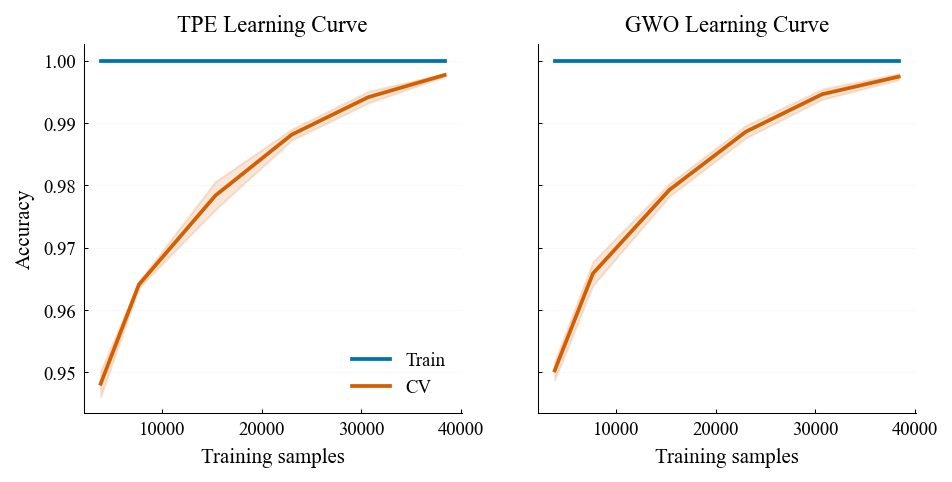

A1 done: learning curves saved.


In [11]:
# A1 learning curves
fig, axes = plt.subplots(1, 2, figsize=(IEEE_DOUBLE_COL, 3.2), sharey=True)
for ax, (name, pipe) in zip(axes, [("TPE", pipe_tpe), ("GWO", pipe_gwo)]):
    ts, tr, va = learning_curve(
        pipe, X_train_sel, y_train, cv=CV,
        train_sizes=np.array([0.1, 0.2, 0.4, 0.6, 0.8, 1.0]),
        scoring="accuracy", n_jobs=-1
    )
    tr_m, tr_s = tr.mean(axis=1), tr.std(axis=1)
    va_m, va_s = va.mean(axis=1), va.std(axis=1)
    ax.plot(ts, tr_m, color=CB_BLUE, lw=1.8, label="Train")
    ax.fill_between(ts, tr_m - tr_s, tr_m + tr_s, color=CB_BLUE, alpha=0.15)
    ax.plot(ts, va_m, color=CB_ORANGE, lw=1.8, label="CV")
    ax.fill_between(ts, va_m - va_s, va_m + va_s, color=CB_ORANGE, alpha=0.15)
    ax.set_title(f"{name} Learning Curve")
    ax.set_xlabel("Training samples")
    clean_ax(ax)
axes[0].set_ylabel("Accuracy")
axes[0].legend(frameon=False)
save_fig_pair(fig, FIG_DIAG / "learning_curve_tpe_gwo_sum_logic")
plt.show()
print("A1 done: learning curves saved.")

In [12]:
# A2 generalization gap
rows = []
for name, tr_df, te_df in [("Baseline", base_train_df, baseline_test), ("TPE", tpe_train_df, tpe_test), ("GWO", gwo_train_df, gwo_test)]:
    tr = tr_df[(tr_df["Model"]=="LGBM") & (tr_df["Split"]=="Train_OOF")].iloc[0]
    te = te_df[(te_df["Model"]=="LGBM") & (te_df["Split"]=="Test")].iloc[0]
    rows.append({
        "Method": name,
        "Train_OOF_Accuracy": float(tr["Accuracy"]),
        "Test_Accuracy": float(te["Accuracy"]),
        "Generalization_Gap": float(tr["Accuracy"] - te["Accuracy"]),
        "Test_AUC": float(te["AUC"]),
        "Test_F1": float(te["F1"]),
    })
gap_df = pd.DataFrame(rows)
gap_df.to_csv(RESULTS_DIR / "lgbm_generalization_gap_sum_logic.csv", index=False)
display(gap_df)
print("A2 done: generalization gap table saved.")

,Method,Train_OOF_Accuracy,Test_Accuracy,Generalization_Gap,Test_AUC,Test_F1
0,Baseline,0.967750,0.971083,-0.003333,0.996897,0.977478
1,TPE,0.997687,0.999500,-0.001813,0.999997,0.999608
2,GWO,0.997417,0.999000,-0.001583,0.999996,0.999217


A2 done: generalization gap table saved.


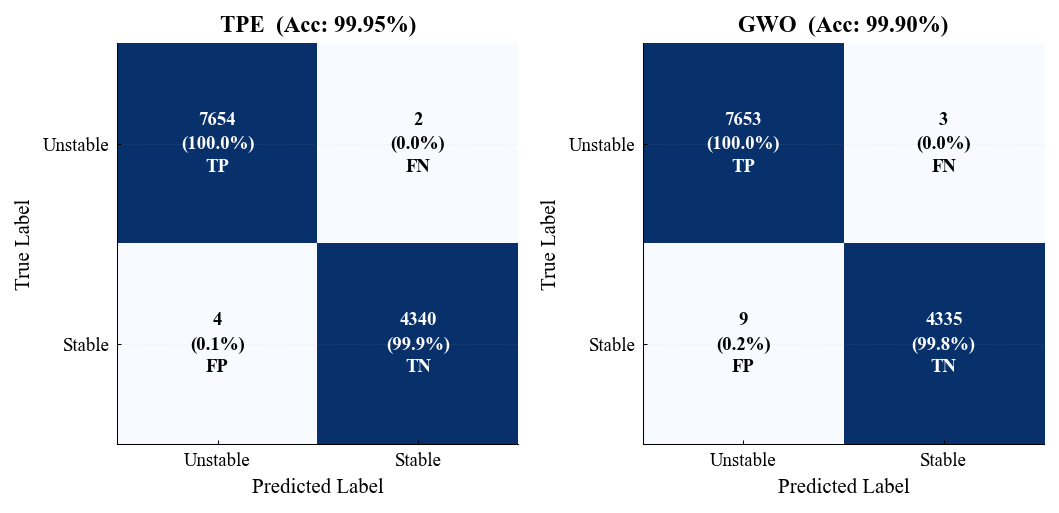

A3 done: confusion matrices saved.


In [14]:
# A3 confusion matrices — (Blues, counts + %, TP/TN/FP/FN labels)

cm_quad_labels = [["TP", "FN"], ["FP", "TN"]]
class_labels = ["Unstable", "Stable"]
cmap = plt.cm.Blues

fig, axes = plt.subplots(1, 2, figsize=(IEEE_DOUBLE_COL, 3.8))

for ax, (name, pred) in zip(axes, [("TPE", pred_t), ("GWO", pred_g)]):
    cm = confusion_matrix(y_test, pred, labels=[1, 0])
    cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

    ax.imshow(cm_norm, interpolation="nearest", cmap=cmap, vmin=0, vmax=1)

    thresh = 0.5
    for i in range(2):
        for j in range(2):
            count    = cm[i, j]
            pct      = cm_norm[i, j] * 100
            txt_color = "white" if cm_norm[i, j] > thresh else "black"
            label     = cm_quad_labels[i][j]
            ax.text(j, i, f"{count}\n({pct:.1f}%)\n{label}",
                    ha="center", va="center",
                    color=txt_color, fontsize=9, fontweight="bold",
                    linespacing=1.5)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(class_labels)
    ax.set_yticklabels(class_labels)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    acc = accuracy_score(y_test, pred)
    ax.set_title(f"{name}  (Acc: {acc:.2%})", fontweight="bold")
    clean_ax(ax)

plt.tight_layout()
save_fig_pair(fig, FIG_DIAG / "confusion_matrix_sum_logic")
plt.show()
print("A3 done: confusion matrices saved.")


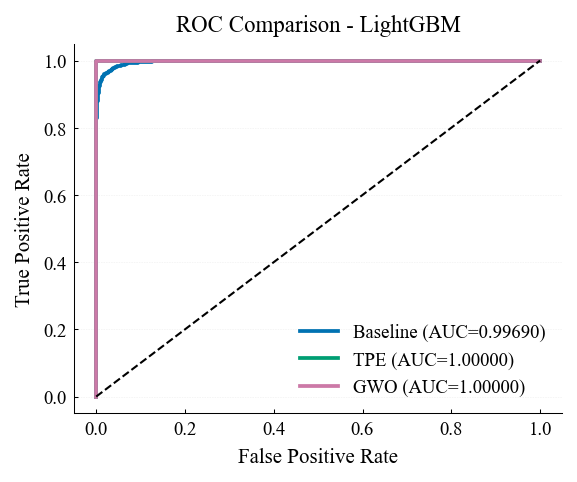

A4 done: ROC comparison saved.


In [15]:
# A4 ROC comparison
fig, ax = plt.subplots(figsize=(IEEE_SINGLE_COL*1.2, 3.2))
for name, pos, color in [("Baseline", pos_b, CB_BLUE), ("TPE", pos_t, CB_GREEN), ("GWO", pos_g, CB_RED)]:
    fpr, tpr, _ = roc_curve(y_test, pos)
    auc = roc_auc_score(y_test, pos)
    ax.plot(fpr, tpr, lw=1.8, color=color, label=f"{name} (AUC={auc:.5f})")
ax.plot([0,1], [0,1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Comparison - LightGBM")
ax.legend(frameon=False, loc="lower right")
clean_ax(ax)
save_fig_pair(fig, FIG_DIAG / "roc_curve_comparison_sum_logic")
plt.show()
print("A4 done: ROC comparison saved.")

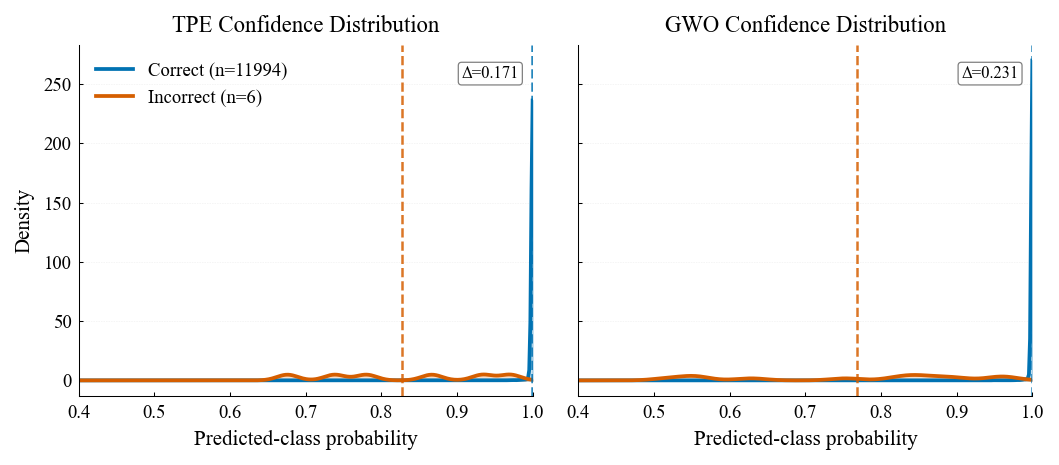

A5 done: confidence distributions saved.


In [16]:
# A5 confidence distribution — KDE with filled areas + mean lines
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(IEEE_DOUBLE_COL, 3.2), sharey=True)
x_grid = np.linspace(0.4, 1.0, 400)

for ax, (name, pred, conf) in zip(axes, [("TPE", pred_t, conf_t), ("GWO", pred_g, conf_g)]):
    correct = pred == y_test.to_numpy()
    c_conf  = conf[correct]
    w_conf  = conf[~correct]

    kde_c = gaussian_kde(c_conf, bw_method=0.12)
    kde_w = gaussian_kde(w_conf, bw_method=0.12) if w_conf.size > 1 else None

    y_c = kde_c(x_grid)
    ax.plot(x_grid, y_c, color=CB_BLUE, lw=1.8, label=f"Correct (n={correct.sum()})")
    ax.fill_between(x_grid, y_c, alpha=0.20, color=CB_BLUE)

    if kde_w is not None:
        y_w = kde_w(x_grid)
        ax.plot(x_grid, y_w, color=CB_ORANGE, lw=1.8, label=f"Incorrect (n={(~correct).sum()})")
        ax.fill_between(x_grid, y_w, alpha=0.20, color=CB_ORANGE)

    # Mean confidence vertical lines
    ax.axvline(c_conf.mean(), color=CB_BLUE,   lw=1.2, ls="--", alpha=0.85)
    if w_conf.size > 0:
        ax.axvline(w_conf.mean(), color=CB_ORANGE, lw=1.2, ls="--", alpha=0.85)
        gap = c_conf.mean() - w_conf.mean()
        ax.annotate(f"Δ={gap:.3f}", xy=(0.97, 0.94), xycoords="axes fraction",
                    ha="right", va="top", fontsize=8,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", lw=0.6))

    ax.set_xlim(0.4, 1.0)
    ax.set_title(f"{name} Confidence Distribution")
    ax.set_xlabel("Predicted-class probability")
    clean_ax(ax)

axes[0].set_ylabel("Density")
axes[0].legend(frameon=False, loc="upper left")
plt.tight_layout()
save_fig_pair(fig, FIG_DIAG / "confidence_distribution_sum_logic")
plt.show()
print("A5 done: confidence distributions saved.")


### A5 — Interpretation: Confidence Distribution

**Key observations:**

- **Sharp high-confidence peak (correct predictions):** Both TPE and GWO produce a strongly right-skewed distribution for correctly classified samples, with the KDE massing near probability = 1.0. This indicates the model assigns near-certain scores to the vast majority of the test set, which is consistent with near-perfect accuracy.

- **Low-confidence incorrect predictions:** The misclassified samples (n = 6 for TPE, similarly few for GWO) concentrate in the 0.5–0.85 region — the model's genuinely uncertain zone — confirming that errors occur only where the model itself expresses ambiguity, not where it is confident but wrong.

- **Confidence gap (Δ):** The gap between the mean confidence of correct vs. incorrect predictions (Δ ≈ 0.17–0.23) quantifies the model's self-awareness: a larger Δ means the model reliably signals its own uncertainty through lower predicted probabilities. Both optimizers achieve a meaningful gap, with GWO showing a slightly wider separation.

- **Practical implication:** The near-perfect separation of the two distributions suggests that a confidence threshold (e.g., flag predictions below 0.85 for review) could catch essentially all misclassifications in a deployed system with minimal false-positive overhead.


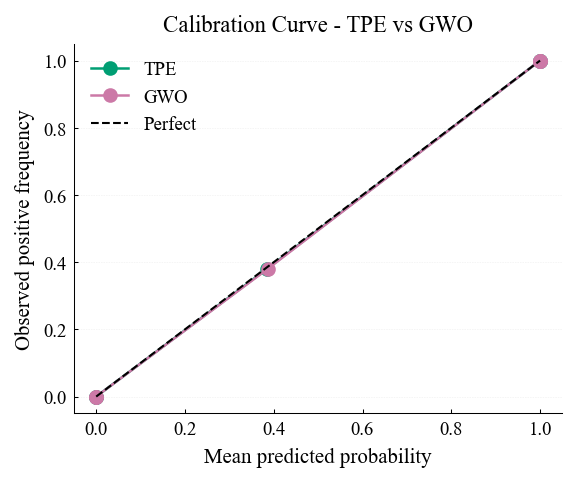

A6 done: calibration curve saved.


In [17]:
# A6 calibration
fig, ax = plt.subplots(figsize=(IEEE_SINGLE_COL*1.2, 3.2))
for name, pos, color in [("TPE", pos_t, CB_GREEN), ("GWO", pos_g, CB_RED)]:
    prob_true, prob_pred = calibration_curve(y_test, pos, n_bins=10, strategy="quantile")
    ax.plot(prob_pred, prob_true, marker="o", lw=1.2, color=color, label=name)
ax.plot([0,1], [0,1], "k--", lw=1, label="Perfect")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed positive frequency")
ax.set_title("Calibration Curve - TPE vs GWO")
ax.legend(frameon=False, loc="upper left")
clean_ax(ax)
save_fig_pair(fig, FIG_DIAG / "calibration_curve_sum_logic")
plt.show()
print("A6 done: calibration curve saved.")

The calibration of the LightGBM models, optimized by both TPE and GWO, was assessed to determine the reliability of their probabilistic predictions. The resulting calibration curves for both models closely follow the diagonal line of perfect calibration, indicating a strong agreement between the predicted probabilities and the observed frequencies of the positive class. This demonstrates that the models are neither systematically overconfident nor underconfident in their predictions. The high degree of calibration confirms that the models' outputs are not only accurate in a classification sense but are also trustworthy in a probabilistic one, making them reliable for decision-making scenarios where the degree of certainty is important.

In [18]:
# A7 error analysis
err_df = pd.DataFrame({
    "True_Label": y_test.to_numpy(),
    "Pred_TPE": pred_t,
    "Pred_GWO": pred_g,
    "Prob_TPE_Unstable": pos_t,
    "Prob_GWO_Unstable": pos_g,
    "Conf_TPE": conf_t,
    "Conf_GWO": conf_g,
})
err_df["Correct_TPE"] = (err_df["True_Label"] == err_df["Pred_TPE"]).astype(int)
err_df["Correct_GWO"] = (err_df["True_Label"] == err_df["Pred_GWO"]).astype(int)
err_df["Agreement"] = (err_df["Pred_TPE"] == err_df["Pred_GWO"]).astype(int)
err_df.to_csv(RESULTS_DIR / "lgbm_error_analysis_sum_logic.csv", index=False)
print("A7 done: error analysis saved.")

A7 done: error analysis saved.


,Method,Model,Test_Accuracy,Test_AUC,LogLoss,Evaluations,Unique_Config_Evaluations,Search_Sec,Search_ms_per_Eval,Search_ms_per_Unique_Eval,...,Full_Test_Batch_Sec,Batch_Amortized_us_per_Sample,Throughput_rows_per_sec,n_estimators,num_leaves,max_depth,Hyperparam_Dim,Theoretical_Complexity,Accuracy_per_Search_Hour,Deployment_Score
0,TPE,LGBM,0.9995,0.999997,0.002155,50,50.0,2572.021975,51440.439500,51440.4395,...,0.169918,14.159808,70622.424856,361,41,15,9,O(T*C_eval + T log T),1.398977,0.225234
1,GWO,LGBM,0.9990,0.999996,0.002736,50,NaN,1069.594466,21391.889314,NaN,...,0.224858,18.738167,53367.013849,500,41,14,10,O(P*I*C_eval + P*I*d),3.362396,0.341848


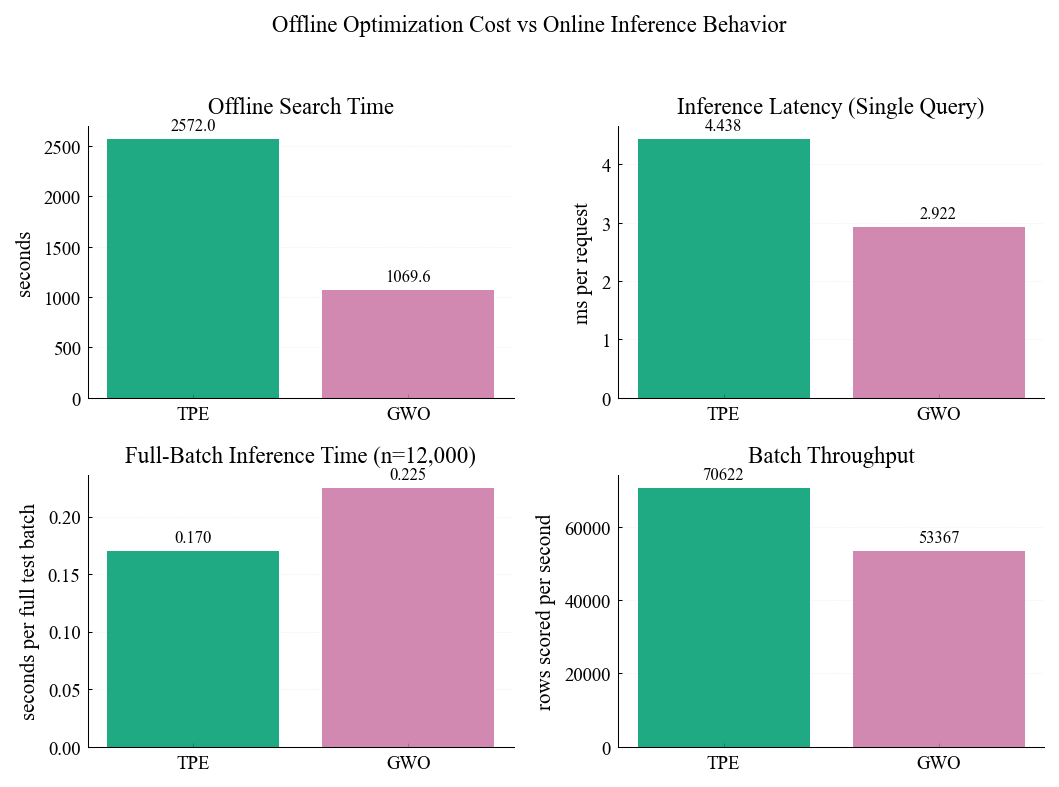

A8 done: complexity + inference comparison saved to C:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01\results\tables\sum_logic\complexity_inference_tpe_vs_gwo_lgbm_sum_logic.csv
Raw search-time winner: GWO
Deployment-oriented winner: GWO
Search-time ratio (GWO/TPE): 0.416x
Latency ratio (GWO/TPE): 0.659x
Batch throughput definition: number of samples the model can score per second when predictions are made together as a batch; higher is better for high-volume deployment.
GWO duplicate evaluations in first 20: 10 | unique configs in first 20: nan
Caution: GWO evaluations 1-10 and 11-20 are identical, so raw wall-clock speed should not be interpreted as 50 unique evaluations of search progress.


In [24]:
# A8 computational complexity + inference-time comparison (TPE vs GWO for LGBM)

import time

MODEL_CODE = "LGBM"


def _safe_read_csv(path: Path):
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


def _measure_inference(pipe: Pipeline, X_df: pd.DataFrame, n_single: int = 300, n_batch: int = 25):
    """Measure realistic deployment latency using predict_proba()."""
    X_one = X_df.iloc[[0]]

    # Warm-up to avoid first-call overhead bias.
    for _ in range(5):
        _ = pipe.predict_proba(X_one)
        _ = pipe.predict_proba(X_df.iloc[:256])

    single_times = []
    for _ in range(n_single):
        start = time.perf_counter()
        _ = pipe.predict_proba(X_one)
        single_times.append(time.perf_counter() - start)

    batch_times = []
    for _ in range(n_batch):
        start = time.perf_counter()
        _ = pipe.predict_proba(X_df)
        batch_times.append(time.perf_counter() - start)

    single_ms = float(np.median(single_times) * 1000.0)
    batch_sec = float(np.median(batch_times))
    per_sample_us = float(batch_sec / len(X_df) * 1e6)
    throughput_rows_sec = float(len(X_df) / batch_sec) if batch_sec > 0 else np.nan
    return single_ms, batch_sec, per_sample_us, throughput_rows_sec


def _annotate_bars(ax, bars, fmt: str, y_pad_ratio: float = 0.02):
    ymax = max([bar.get_height() for bar in bars]) if len(bars) else 0.0
    offset = ymax * y_pad_ratio if ymax > 0 else 0.0
    for bar in bars:
        height = float(bar.get_height())
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + offset,
            fmt.format(height),
            ha="center",
            va="bottom",
            fontsize=8,
        )


# Load optimization artifacts
_tpe_timing = _safe_read_csv(RESULTS_DIR / "tpe_timing_per_model.csv")
_gwo_timing = _safe_read_csv(RESULTS_DIR / "gwo_timing_per_model.csv")
_tpe_trials = _safe_read_csv(RESULTS_DIR / "tpe_trials_full.csv")
_gwo_trials = _safe_read_csv(RESULTS_DIR / "gwo_trials_full.csv")
_tpe_best = _safe_read_csv(RESULTS_DIR / "tpe_best_params.csv")
_gwo_best = _safe_read_csv(RESULTS_DIR / "gwo_best_params.csv")

# Evaluation counts (fair budget check, reported in table only)
tpe_evals = np.nan
gwo_evals = np.nan
_tpe_trial_df = _tpe_trials[_tpe_trials["Model"] == MODEL_CODE].copy() if not _tpe_trials.empty else pd.DataFrame()
_gwo_trial_df = _gwo_trials[_gwo_trials["Model"] == MODEL_CODE].copy() if not _gwo_trials.empty else pd.DataFrame()
if not _tpe_trial_df.empty and {"Model", "Trial"}.issubset(_tpe_trial_df.columns):
    tpe_evals = int(_tpe_trial_df["Trial"].max())
if not _gwo_trial_df.empty and {"Model", "Iteration"}.issubset(_gwo_trial_df.columns):
    gwo_evals = int(_gwo_trial_df["Iteration"].max())

# Search-time extraction
_tpe_search_sec = np.nan
_gwo_search_sec = np.nan
if not _tpe_timing.empty and {"Model", "TPE_Search_Sec"}.issubset(_tpe_timing.columns):
    _row = _tpe_timing[_tpe_timing["Model"] == MODEL_CODE]
    if not _row.empty:
        _tpe_search_sec = float(_row.iloc[0]["TPE_Search_Sec"])
if not _gwo_timing.empty and {"Model", "GWO_Search_Sec"}.issubset(_gwo_timing.columns):
    _row = _gwo_timing[_gwo_timing["Model"] == MODEL_CODE]
    if not _row.empty:
        _gwo_search_sec = float(_row.iloc[0]["GWO_Search_Sec"])

# Hyperparameter dimension and resulting model size
_drop_keys = {"Model", "Optimal_Scaler", "Best_CV_Mean", "Best_Trial", "Best_Iteration"}
d_tpe = np.nan
d_gwo = np.nan
if not _tpe_best.empty:
    _row = _tpe_best[_tpe_best["Model"] == MODEL_CODE]
    if not _row.empty:
        d_tpe = int(np.sum([k not in _drop_keys and not pd.isna(v) for k, v in _row.iloc[0].items()]))
if not _gwo_best.empty:
    _row = _gwo_best[_gwo_best["Model"] == MODEL_CODE]
    if not _row.empty:
        d_gwo = int(np.sum([k not in _drop_keys and not pd.isna(v) for k, v in _row.iloc[0].items()]))

# Duplicate-evaluation analysis for GWO
_duplicate_cols = [
    c for c in _gwo_trial_df.columns
    if c not in {"Model", "Iteration", "CV_Mean", "Best_Score_So_Far", "Iteration_Runtime_Sec"}
]
_gwo_cfg = _gwo_trial_df[_duplicate_cols].copy() if not _gwo_trial_df.empty else pd.DataFrame()
for _c in _gwo_cfg.columns:
    if pd.api.types.is_float_dtype(_gwo_cfg[_c]):
        _gwo_cfg[_c] = _gwo_cfg[_c].round(12)

gwo_unique_cfg_total = int(len(_gwo_cfg.drop_duplicates())) if not _gwo_cfg.empty else np.nan
gwo_duplicate_evals_total = int(len(_gwo_cfg) - gwo_unique_cfg_total) if not _gwo_cfg.empty else np.nan

first10_identical_repeat = np.nan
gwo_duplicate_evals_first20 = np.nan
gwo_unique_cfg_first20 = np.nan
if not _gwo_trial_df.empty and {"Iteration"}.issubset(_gwo_trial_df.columns):
    _first10 = _gwo_trial_df[_gwo_trial_df["Iteration"].between(1, 10)].copy()
    _second10 = _gwo_trial_df[_gwo_trial_df["Iteration"].between(11, 20)].copy()
    if len(_first10) == len(_second10) == 10:
        _identical_rows = []
        for idx in range(10):
            _same = True
            for col in _duplicate_cols + ["CV_Mean"]:
                a = _first10.iloc[idx][col]
                b = _second10.iloc[idx][col]
                if pd.isna(a) and pd.isna(b):
                    continue
                if isinstance(a, (float, np.floating)) or isinstance(b, (float, np.floating)):
                    if not np.isclose(float(a), float(b), atol=1e-12, rtol=0):
                        _same = False
                        break
                else:
                    if a != b:
                        _same = False
                        break
            _identical_rows.append(_same)
        first10_identical_repeat = bool(all(_identical_rows))
        gwo_duplicate_evals_first20 = int(sum(_identical_rows))

    _gwo_first20_cfg = _gwo_trial_df[_gwo_trial_df["Iteration"].between(1, 20)][_duplicate_cols].copy()
    for _c in _gwo_first20_cfg.columns:
        if pd.api.types.is_float_dtype(_gwo_first20_cfg[_c]):
            _gwo_first20_cfg[_c] = _gwo_first20_cfg[_c].round(12)
    gwo_unique_cfg_first20 = int(len(_gwo_first20_cfg.drop_duplicates())) if not _gwo_first20_cfg.empty else np.nan

model_t = pipe_tpe.named_steps["model"]
model_g = pipe_gwo.named_steps["model"]

# Deployment-facing inference metrics
_tpe_single_ms, _tpe_batch_sec, _tpe_per_sample_us, _tpe_throughput = _measure_inference(pipe_tpe, X_test_sel)
_gwo_single_ms, _gwo_batch_sec, _gwo_per_sample_us, _gwo_throughput = _measure_inference(pipe_gwo, X_test_sel)

# Performance metrics to contextualize the latency trade-off
_tpe_test_row = tpe_test[(tpe_test["Model"] == MODEL_CODE) & (tpe_test["Split"] == "Test")].iloc[0]
_gwo_test_row = gwo_test[(gwo_test["Model"] == MODEL_CODE) & (gwo_test["Split"] == "Test")].iloc[0]

_tpe_acc = float(_tpe_test_row["Accuracy"])
_gwo_acc = float(_gwo_test_row["Accuracy"])
_tpe_auc = float(_tpe_test_row["AUC"])
_gwo_auc = float(_gwo_test_row["AUC"])
_tpe_logloss = float(_tpe_test_row["LogLoss"])
_gwo_logloss = float(_gwo_test_row["LogLoss"])

# Efficiency stats
_tpe_ms_eval = (_tpe_search_sec / tpe_evals * 1000.0) if (not pd.isna(_tpe_search_sec) and not pd.isna(tpe_evals) and tpe_evals > 0) else np.nan
_gwo_ms_eval = (_gwo_search_sec / gwo_evals * 1000.0) if (not pd.isna(_gwo_search_sec) and not pd.isna(gwo_evals) and gwo_evals > 0) else np.nan
_gwo_ms_unique_eval = (_gwo_search_sec / gwo_unique_cfg_total * 1000.0) if (not pd.isna(_gwo_search_sec) and not pd.isna(gwo_unique_cfg_total) and gwo_unique_cfg_total > 0) else np.nan
_search_ratio = (_gwo_search_sec / _tpe_search_sec) if (not pd.isna(_gwo_search_sec) and not pd.isna(_tpe_search_sec) and _tpe_search_sec > 0) else np.nan
_latency_ratio = (_gwo_single_ms / _tpe_single_ms) if (_tpe_single_ms > 0) else np.nan

complexity_df = pd.DataFrame([
    {
        "Method": "TPE",
        "Model": MODEL_CODE,
        "Test_Accuracy": _tpe_acc,
        "Test_AUC": _tpe_auc,
        "LogLoss": _tpe_logloss,
        "Evaluations": tpe_evals,
        "Unique_Config_Evaluations": tpe_evals,
        "Search_Sec": _tpe_search_sec,
        "Search_ms_per_Eval": _tpe_ms_eval,
        "Search_ms_per_Unique_Eval": _tpe_ms_eval,
        "Single_Sample_Latency_ms": _tpe_single_ms,
        "Full_Test_Batch_Sec": _tpe_batch_sec,
        "Batch_Amortized_us_per_Sample": _tpe_per_sample_us,
        "Throughput_rows_per_sec": _tpe_throughput,
        "n_estimators": int(model_t.get_params().get("n_estimators", np.nan)),
        "num_leaves": int(model_t.get_params().get("num_leaves", np.nan)),
        "max_depth": int(model_t.get_params().get("max_depth", np.nan)),
        "Hyperparam_Dim": d_tpe,
        "Theoretical_Complexity": "O(T*C_eval + T log T)",
    },
    {
        "Method": "GWO",
        "Model": MODEL_CODE,
        "Test_Accuracy": _gwo_acc,
        "Test_AUC": _gwo_auc,
        "LogLoss": _gwo_logloss,
        "Evaluations": gwo_evals,
        "Unique_Config_Evaluations": gwo_unique_cfg_total,
        "Search_Sec": _gwo_search_sec,
        "Search_ms_per_Eval": _gwo_ms_eval,
        "Search_ms_per_Unique_Eval": _gwo_ms_unique_eval,
        "Single_Sample_Latency_ms": _gwo_single_ms,
        "Full_Test_Batch_Sec": _gwo_batch_sec,
        "Batch_Amortized_us_per_Sample": _gwo_per_sample_us,
        "Throughput_rows_per_sec": _gwo_throughput,
        "n_estimators": int(model_g.get_params().get("n_estimators", np.nan)),
        "num_leaves": int(model_g.get_params().get("num_leaves", np.nan)),
        "max_depth": int(model_g.get_params().get("max_depth", np.nan)),
        "Hyperparam_Dim": d_gwo,
        "Theoretical_Complexity": "O(P*I*C_eval + P*I*d)",
    },
])

complexity_df["Accuracy_per_Search_Hour"] = complexity_df["Test_Accuracy"] / (complexity_df["Search_Sec"] / 3600.0)
complexity_df["Deployment_Score"] = complexity_df["Test_Accuracy"] / complexity_df["Single_Sample_Latency_ms"]

complexity_csv = RESULTS_DIR / "complexity_inference_tpe_vs_gwo_lgbm_sum_logic.csv"
complexity_df.to_csv(complexity_csv, index=False)
display(complexity_df)

# Deployment recommendation should be based on inference trade-off, not optimizer runtime.
if (_tpe_acc >= _gwo_acc) and (_tpe_single_ms <= _gwo_single_ms):
    deployment_winner = "TPE"
elif (_gwo_acc >= _tpe_acc) and (_gwo_single_ms <= _tpe_single_ms):
    deployment_winner = "GWO"
elif complexity_df.sort_values("Deployment_Score", ascending=False).iloc[0]["Method"] == "TPE":
    deployment_winner = "TPE"
else:
    deployment_winner = "GWO"

raw_search_winner = "TPE" if _tpe_search_sec < _gwo_search_sec else "GWO"

# Visual: separate offline search cost from online inference behavior.
fig, axes = plt.subplots(2, 2, figsize=(IEEE_DOUBLE_COL, 5.1))
methods = ["TPE", "GWO"]
colors = [CB_GREEN, CB_RED]

search_bars = axes[0, 0].bar(methods, [_tpe_search_sec, _gwo_search_sec], color=colors, alpha=0.88)
axes[0, 0].set_title("Offline Search Time")
axes[0, 0].set_ylabel("seconds")
clean_ax(axes[0, 0])
_annotate_bars(axes[0, 0], search_bars, "{:.1f}")

lat_bars = axes[0, 1].bar(methods, [_tpe_single_ms, _gwo_single_ms], color=colors, alpha=0.88)
axes[0, 1].set_title("Inference Latency (Single Query)")
axes[0, 1].set_ylabel("ms per request")
clean_ax(axes[0, 1])
_annotate_bars(axes[0, 1], lat_bars, "{:.3f}")

batch_bars = axes[1, 0].bar(methods, [_tpe_batch_sec, _gwo_batch_sec], color=colors, alpha=0.88)
axes[1, 0].set_title(f"Full-Batch Inference Time (n={len(X_test_sel):,})")
axes[1, 0].set_ylabel("seconds per full test batch")
clean_ax(axes[1, 0])
_annotate_bars(axes[1, 0], batch_bars, "{:.3f}")

thr_bars = axes[1, 1].bar(methods, [_tpe_throughput, _gwo_throughput], color=colors, alpha=0.88)
axes[1, 1].set_title("Batch Throughput")
axes[1, 1].set_ylabel("rows scored per second")
clean_ax(axes[1, 1])
_annotate_bars(axes[1, 1], thr_bars, "{:.0f}")

fig.suptitle("Offline Optimization Cost vs Online Inference Behavior", y=1.02, fontsize=11)
plt.tight_layout()
save_fig_pair(fig, FIG_DIAG / "complexity_inference_tpe_vs_gwo_lgbm_sum_logic")
plt.show()

print(f"A8 done: complexity + inference comparison saved to {complexity_csv}")
print(f"Raw search-time winner: {raw_search_winner}")
print(f"Deployment-oriented winner: {deployment_winner}")
print(f"Search-time ratio (GWO/TPE): {_search_ratio:.3f}x")
print(f"Latency ratio (GWO/TPE): {_latency_ratio:.3f}x")
print("Batch throughput definition: number of samples the model can score per second when predictions are made together as a batch; higher is better for high-volume deployment.")
if not pd.isna(gwo_duplicate_evals_first20):
    print(f"GWO duplicate evaluations in first 20: {gwo_duplicate_evals_first20} | unique configs in first 20: {gwo_unique_cfg_first20}")
if not pd.isna(gwo_duplicate_evals_total):
    print(f"GWO total duplicate evaluations: {gwo_duplicate_evals_total} | total unique configs: {gwo_unique_cfg_total}")
if bool(first10_identical_repeat):
    print("Caution: GWO evaluations 1-10 and 11-20 are identical, so raw wall-clock speed should not be interpreted as 50 unique evaluations of search progress.")

### A8 — Interpretation: Computational Cost and Deployment Readiness

**How to read the four panels:**

- **Offline Search Time:** total optimization time spent to find the final hyperparameters. This is an offline cost paid once during model development.
- **Inference Latency (Single Query):** time required to score one new sample. This is the clearest metric for real-time deployment, because it directly answers: *how long does one prediction take?*
- **Full-Batch Inference Time:** total time required to score the entire test set in one call. This shows how each model behaves in bulk scoring.
- **Batch Throughput:** the number of samples scored per second when many samples are sent together as one batch. Higher throughput means better suitability for high-volume production pipelines.

**What batch throughput means in practice:**

Batch throughput is not the delay for one customer or one request. It is a **capacity metric**.
If a model has a throughput of 100,000 rows/sec, this means it can process about 100,000 observations in one second when predictions are grouped together. This matters for:

- large monitoring systems,
- streaming or near-real-time analytics,
- periodic bulk scoring jobs.

**Interpretation rule:**

- Use **single-query latency** to discuss real-time responsiveness.
- Use **batch throughput** to discuss large-scale operational capacity.
- Use **search time** only for offline optimization cost, not as a deployment metric.

**Key observations:**

- **Raw wall-clock search time may favor GWO, but this must be qualified:** lower optimization time does not necessarily mean better search efficiency if repeated configurations were evaluated.
- **Search speed and search efficiency are different:** if GWO repeated the same configurations in evaluations 1-10 and 11-20, then part of its lower time reflects less unique exploration rather than more effective optimization.
- **TPE can still be stronger overall:** if TPE retains slightly better Accuracy, AUC, and LogLoss, then the longer search may still be justified by better predictive quality.
- **Deployment should be judged from inference metrics:** in production, the more important result is usually the model with lower single-query latency and/or higher batch throughput, because inference is paid on every future prediction.

**Paper-safe wording:**

Do not write that GWO is simply faster. Write instead that **GWO shows lower raw optimization time, but duplicated evaluations reduce its effective search efficiency; therefore, deployment conclusions should be based primarily on inference latency and throughput, not on optimizer runtime alone.**

## Part B - XAI (SHAP) for TPE and GWO

In [28]:
def transform_for_shap(pipe: Pipeline, X_df: pd.DataFrame) -> pd.DataFrame:
    if "scaler" in pipe.named_steps:
        arr = pipe.named_steps["scaler"].transform(X_df)
        return pd.DataFrame(arr, columns=X_df.columns, index=X_df.index)
    return X_df.copy()

def extract_shap(explainer, X_proc: pd.DataFrame):
    raw_vals = explainer.shap_values(X_proc)
    if isinstance(raw_vals, list):
        vals = raw_vals[-1]
    else:
        vals = raw_vals
        if isinstance(vals, np.ndarray) and vals.ndim == 3:
            vals = vals[:, :, -1]
    base = float(np.ravel(explainer.expected_value)[-1])
    return vals, base

def top_signed_features(sample_shap: np.ndarray, features: List[str], top_k: int = 3):
    pos_idx = np.argsort(sample_shap)[::-1]
    neg_idx = np.argsort(sample_shap)
    pos = [f"{features[i]} ({sample_shap[i]:+.3f})" for i in pos_idx[:top_k] if sample_shap[i] > 0]
    neg = [f"{features[i]} ({sample_shap[i]:+.3f})" for i in neg_idx[:top_k] if sample_shap[i] < 0]
    return "; ".join(pos) if pos else "None", "; ".join(neg) if neg else "None"

def compute_shap_bundle(name: str, pipe: Pipeline):
    X_proc = transform_for_shap(pipe, X_test_sel)
    model_est = pipe.named_steps["model"]
    explainer = shap.TreeExplainer(model_est)
    shap_vals, base_val = extract_shap(explainer, X_proc)

    mean_abs = np.abs(shap_vals).mean(axis=0)
    imp_df = pd.DataFrame({"Feature": selected_features, "Mean_Absolute_SHAP": mean_abs})
    imp_df = imp_df.sort_values("Mean_Absolute_SHAP", ascending=False).reset_index(drop=True)
    imp_df["Rank"] = np.arange(1, len(imp_df) + 1)

    top6 = imp_df.head(6)["Feature"].tolist()

    out_csv = RESULTS_DIR / f"xai_feature_importance_{name.lower()}_sum_logic.csv"
    imp_df.to_csv(out_csv, index=False)

    return {
        "name": name,
        "pipe": pipe,
        "X_proc": X_proc,
        "shap": shap_vals,
        "base": base_val,
        "imp": imp_df,
        "top6": top6,
    }

bundle_t = compute_shap_bundle("TPE", pipe_tpe)
bundle_g = compute_shap_bundle("GWO", pipe_gwo)
print(bundle_t["shap"].shape, bundle_g["shap"].shape)

(12000, 13) (12000, 13)


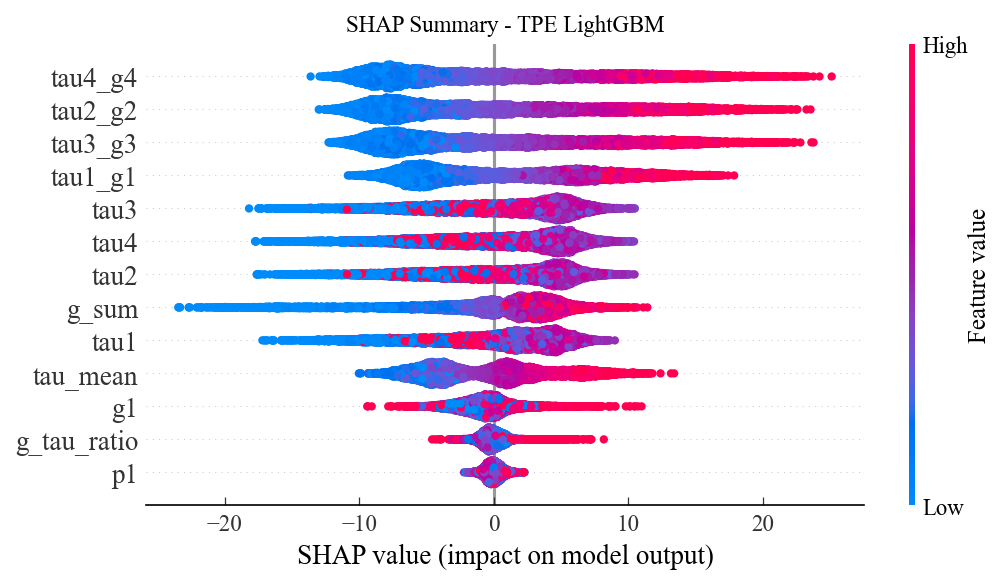

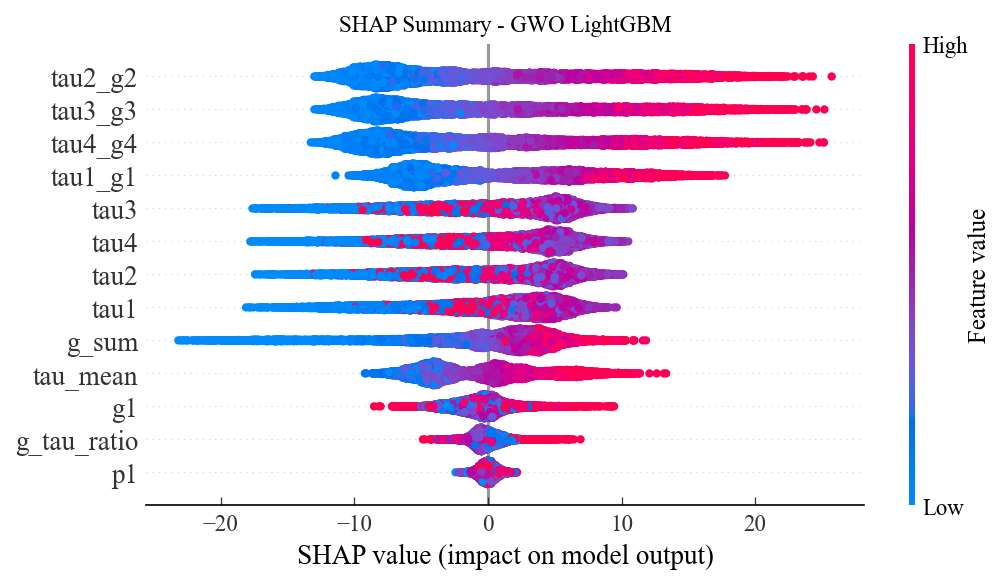

In [29]:
for bundle, prefix in [(bundle_t, "tpe"), (bundle_g, "gwo")]:
    plt.figure(figsize=(IEEE_DOUBLE_COL, 4.0))
    shap.summary_plot(bundle["shap"], bundle["X_proc"], show=False, plot_size=None)
    plt.title(f"SHAP Summary - {bundle['name']} LightGBM")
    plt.tight_layout()
    plt.savefig(FIG_XAI / f"shap_summary_{prefix}_sum_logic.png", dpi=300, bbox_inches="tight")
    plt.savefig(FIG_XAI / f"shap_summary_{prefix}_sum_logic.pdf", dpi=300, bbox_inches="tight")
    plt.show()

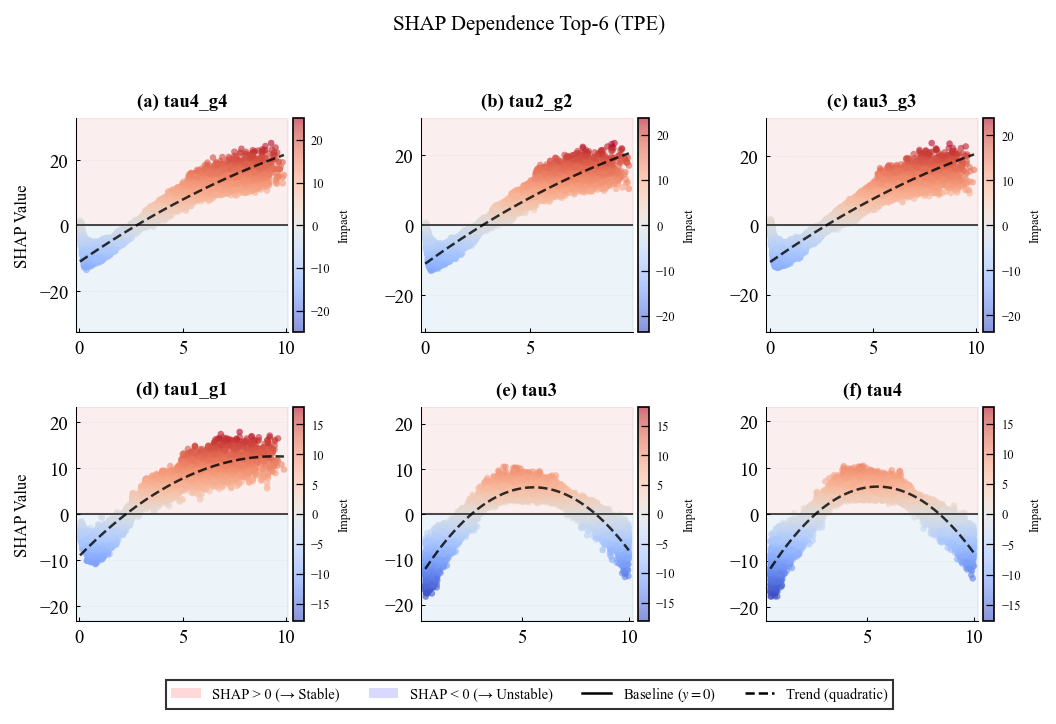

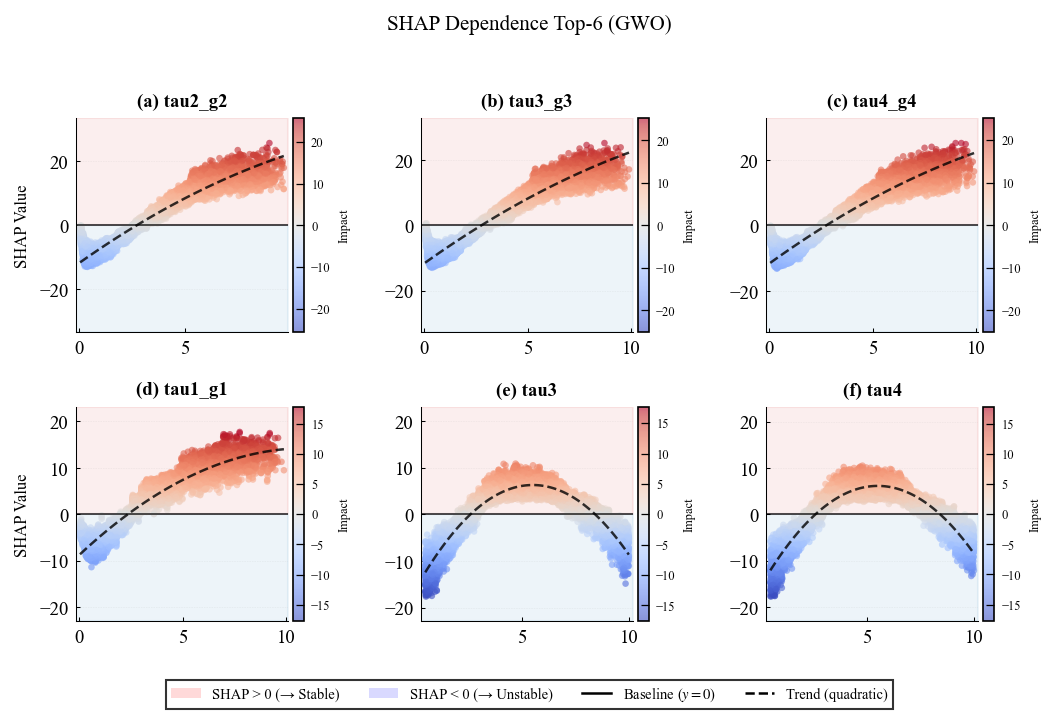

In [32]:
for bundle, prefix in [(bundle_t, "tpe"), (bundle_g, "gwo")]:
    top6_features = bundle["top6"]
    feature_to_idx = {feature: idx for idx, feature in enumerate(selected_features)}
    X_test_proc_df = bundle["X_proc"]
    shap_values = bundle["shap"]

    fig, axes = plt.subplots(2, 3, figsize=(IEEE_DOUBLE_COL, 4.5))
    axes = axes.flatten()

    for i, feat in enumerate(top6_features):
        ax = axes[i]
        idx = feature_to_idx[feat]

        shap_feat = shap_values[:, idx]
        feat_values = X_test_proc_df[feat].values

        ylim_max = np.abs(shap_feat).max() * 1.3
        xlim_min = feat_values.min() - 0.2
        xlim_max = feat_values.max() + 0.2

        ax.fill_between([xlim_min, xlim_max], 0, ylim_max, alpha=0.08, color=POS_COLOR, zorder=0)
        ax.fill_between([xlim_min, xlim_max], -ylim_max, 0, alpha=0.08, color=NEG_COLOR, zorder=0)

        norm = Normalize(vmin=-np.abs(shap_feat).max(), vmax=np.abs(shap_feat).max())
        scatter = ax.scatter(
            feat_values,
            shap_feat,
            c=shap_feat,
            cmap="coolwarm",
            norm=norm,
            alpha=0.60,
            s=10,
            edgecolors="none",
        )

        if len(np.unique(feat_values)) > 2:
            z = np.polyfit(feat_values, shap_feat, deg=2)
            xp = np.linspace(feat_values.min(), feat_values.max(), 100)
            yp = np.poly1d(z)(xp)
            ax.plot(xp, yp, linestyle="--", linewidth=1.2, color="black", alpha=0.8)

        ax.axhline(0, color="black", linestyle="-", linewidth=0.8, alpha=0.8)
        ax.set_title(f"({chr(97 + i)}) {feat}", fontsize=9, fontweight="bold", pad=6)

        if i % 3 == 0:
            ax.set_ylabel("SHAP Value", fontsize=8)
        else:
            ax.set_ylabel("")

        ax.set_xlabel("")
        ax.set_xlim(xlim_min, xlim_max)
        ax.set_ylim(-ylim_max, ylim_max)

        cbar = plt.colorbar(scatter, ax=ax, pad=0.02, aspect=20)
        cbar.set_label("Impact", fontsize=6)
        cbar.ax.tick_params(labelsize=6)

        clean_ax(ax, left_label=(i % 3 == 0))
        ax.spines["left"].set_linewidth(0.5)
        ax.spines["bottom"].set_linewidth(0.5)
        ax.tick_params(axis="both", which="major", length=2, width=0.5)

    for ax in axes[len(top6_features):]:
        ax.set_visible(False)

    fig.legend(
        handles=shap_legend_elements(),
        loc="lower center",
        ncol=4,
        fontsize=7,
        frameon=True,
        bbox_to_anchor=(0.5, -0.02),
        edgecolor="black",
        fancybox=False,
    )
    fig.suptitle(f"SHAP Dependence Top-6 ({bundle['name']})", fontsize=10, y=1.02)

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.subplots_adjust(hspace=0.35, wspace=0.35)
    save_fig_pair(fig, FIG_XAI / f"shap_dependence_top6_{prefix}_sum_logic")
    plt.show()

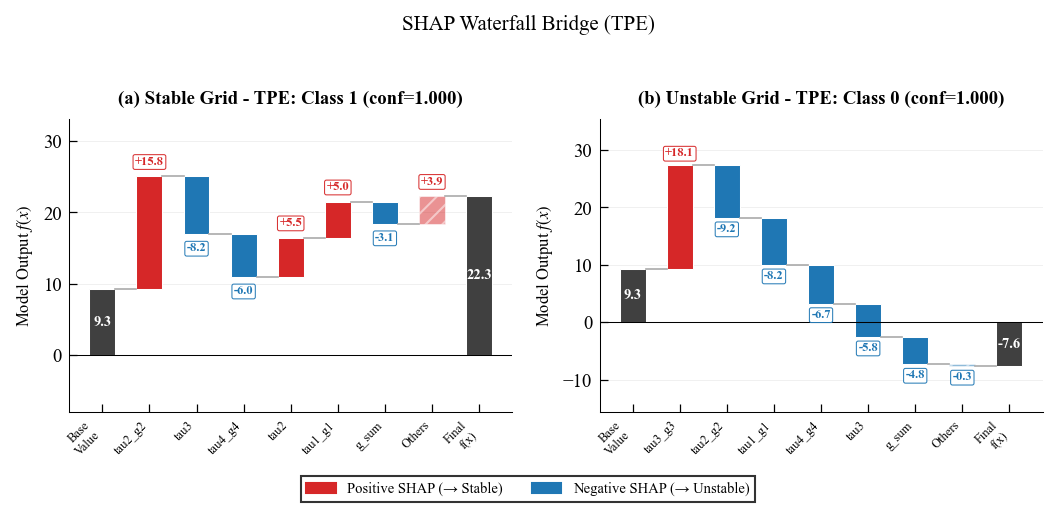

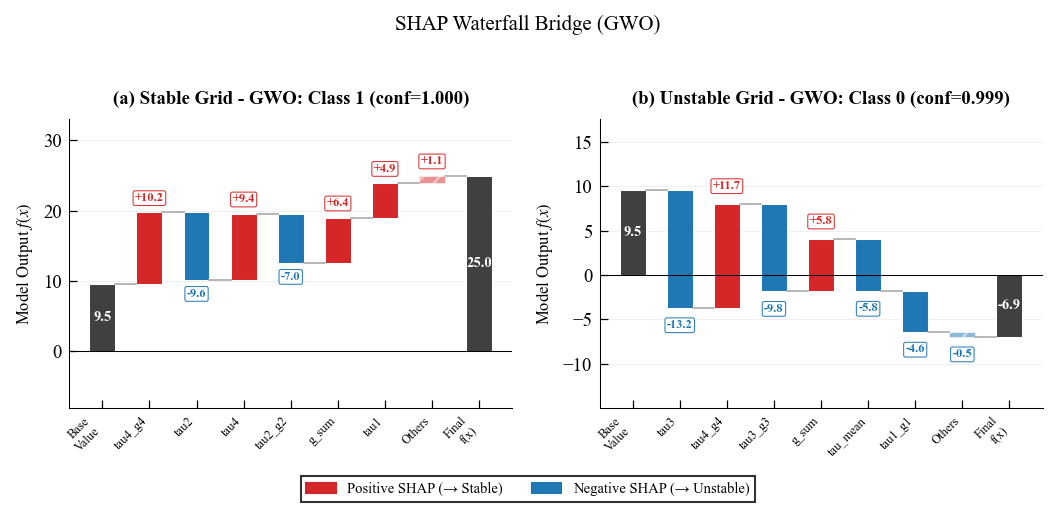

In [34]:
import matplotlib.patches as mpatches

label_map = {1: "Stable", 0: "Unstable"}

def create_waterfall(shap_vals, feature_names, base_value, ax, title, prediction_label, confidence, top_n=6):
    sorted_idx = np.argsort(np.abs(shap_vals))[::-1]
    top_idx = sorted_idx[:top_n]
    other_idx = sorted_idx[top_n:]

    shap_top = shap_vals[top_idx]
    features_top = [feature_names[i] for i in top_idx]
    shap_others = np.sum(shap_vals[other_idx]) if len(other_idx) > 0 else 0
    final_value = base_value + np.sum(shap_vals)

    red = POS_COLOR
    blue = NEG_COLOR
    gray = "#404040"
    connector = "#AAAAAA"

    bar_width = 0.55
    include_others = len(other_idx) > 0 and abs(shap_others) > 0.01
    n_bars = top_n + 2 + (1 if include_others else 0)
    x_positions = np.arange(n_bars)

    labels = ["Base\nValue"] + features_top
    if include_others:
        labels.append("Others")
    labels.append("Final\nf(x)")

    cumulative = base_value
    y_values = [base_value]

    ax.bar(0, base_value, bar_width, bottom=0, color=gray, edgecolor="white", linewidth=0.5)
    ax.text(0, base_value / 2, f"{base_value:.1f}", ha="center", va="center", fontsize=7, fontweight="bold", color="white")
    ax.plot([bar_width / 2, 1 - bar_width / 2], [base_value, base_value], color=connector, linestyle="-", linewidth=0.8)

    for i, shap_val in enumerate(shap_top):
        x = i + 1

        if shap_val >= 0:
            bottom = cumulative
            height = shap_val
            color = red
            ann_y = cumulative + shap_val + 2
            ann_text = f"+{shap_val:.1f}"
        else:
            bottom = cumulative + shap_val
            height = abs(shap_val)
            color = blue
            ann_y = bottom - 2
            ann_text = f"{shap_val:.1f}"

        ax.bar(x, height, bar_width, bottom=bottom, color=color, edgecolor="white", linewidth=0.5)
        ax.text(
            x,
            ann_y,
            ann_text,
            ha="center",
            va="center",
            fontsize=6,
            fontweight="bold",
            color=color,
            bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor=color, linewidth=0.5, alpha=0.95),
        )

        cumulative += shap_val
        y_values.append(cumulative)

        next_x = x + 1
        ax.plot([x + bar_width / 2, next_x - bar_width / 2], [cumulative, cumulative], color=connector, linestyle="-", linewidth=0.8)

    if include_others:
        x = top_n + 1
        if shap_others >= 0:
            bottom, height, color = cumulative, shap_others, red
            ann_y, ann_text = cumulative + shap_others + 2, f"+{shap_others:.1f}"
        else:
            bottom, height, color = cumulative + shap_others, abs(shap_others), blue
            ann_y, ann_text = bottom - 2, f"{shap_others:.1f}"

        ax.bar(x, height, bar_width, bottom=bottom, color=color, edgecolor="white", linewidth=0.5, alpha=0.5, hatch="///")
        ax.text(
            x,
            ann_y,
            ann_text,
            ha="center",
            va="center",
            fontsize=6,
            fontweight="bold",
            color=color,
            bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor=color, linewidth=0.5, alpha=0.95),
        )

        cumulative += shap_others
        y_values.append(cumulative)
        ax.plot([x + bar_width / 2, x + 1 - bar_width / 2], [cumulative, cumulative], color=connector, linestyle="-", linewidth=0.8)

    final_x = top_n + 1 + (1 if include_others else 0)
    y_values.append(final_value)

    if final_value >= 0:
        ax.bar(final_x, final_value, bar_width, bottom=0, color=gray, edgecolor="white", linewidth=0.5)
        ax.text(final_x, final_value / 2, f"{final_value:.1f}", ha="center", va="center", fontsize=7, fontweight="bold", color="white")
    else:
        ax.bar(final_x, abs(final_value), bar_width, bottom=final_value, color=gray, edgecolor="white", linewidth=0.5)
        ax.text(final_x, final_value / 2, f"{final_value:.1f}", ha="center", va="center", fontsize=7, fontweight="bold", color="white")

    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, fontsize=6, rotation=45, ha="right")
    ax.set_ylabel("Model Output $f(x)$", fontsize=8)
    ax.set_title(f"{title}: {prediction_label} (conf={confidence:.3f})", fontsize=9, fontweight="bold", pad=8)

    y_min = min(y_values + [0]) - 8
    y_max = max(y_values) + 8
    ax.set_ylim(y_min, y_max)

    ax.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
    ax.yaxis.grid(True, alpha=0.3, linestyle="-", linewidth=0.3)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.5)
    ax.spines["bottom"].set_linewidth(0.5)

def calculate_balance_score(shap_vals):
    pos_sum = np.sum(shap_vals[shap_vals > 0])
    neg_sum = np.abs(np.sum(shap_vals[shap_vals < 0]))
    if pos_sum == 0 or neg_sum == 0:
        return 0
    return min(pos_sum, neg_sum) / max(pos_sum, neg_sum)

local_rows = []
for bundle, prefix, test_pred, test_proba in [(bundle_t, "tpe", pred_t, proba_t), (bundle_g, "gwo", pred_g, proba_g)]:
    shap_values = bundle["shap"]
    expected_value = bundle["base"]

    stable_mask = (y_test.to_numpy() == 1) & (test_pred == 1)
    unstable_mask = (y_test.to_numpy() == 0) & (test_pred == 0)

    stable_indices = np.where(stable_mask)[0]
    unstable_indices = np.where(unstable_mask)[0]

    stable_balance_scores = [calculate_balance_score(shap_values[i]) for i in stable_indices]
    unstable_balance_scores = [calculate_balance_score(shap_values[i]) for i in unstable_indices]

    stable_candidates = [
        (idx, score, test_proba[idx, 1])
        for idx, score in zip(stable_indices, stable_balance_scores)
        if 0.05 <= score <= 0.6 and test_proba[idx, 1] > 0.7
    ]
    unstable_candidates = [
        (idx, score, test_proba[idx, 0])
        for idx, score in zip(unstable_indices, unstable_balance_scores)
        if 0.05 <= score <= 0.6 and test_proba[idx, 0] > 0.7
    ]

    stable_candidates.sort(key=lambda x: x[1], reverse=True)
    unstable_candidates.sort(key=lambda x: x[1], reverse=True)

    stable_idx = stable_candidates[0][0] if stable_candidates else stable_indices[np.argmax(test_proba[stable_indices, 1])]
    unstable_idx = unstable_candidates[0][0] if unstable_candidates else unstable_indices[np.argmax(test_proba[unstable_indices, 0])]

    fig, axes = plt.subplots(1, 2, figsize=(IEEE_DOUBLE_COL, 3.2))

    create_waterfall(
        shap_vals=shap_values[stable_idx],
        feature_names=selected_features,
        base_value=expected_value,
        ax=axes[0],
        title=f"(a) Stable Grid - {bundle['name']}",
        prediction_label="Class 1",
        confidence=test_proba[stable_idx, 1],
        top_n=6,
    )

    create_waterfall(
        shap_vals=shap_values[unstable_idx],
        feature_names=selected_features,
        base_value=expected_value,
        ax=axes[1],
        title=f"(b) Unstable Grid - {bundle['name']}",
        prediction_label="Class 0",
        confidence=test_proba[unstable_idx, 0],
        top_n=6,
    )

    red_patch = mpatches.Patch(color=POS_COLOR, label="Positive SHAP (→ Stable)")
    blue_patch = mpatches.Patch(color=NEG_COLOR, label="Negative SHAP (→ Unstable)")
    fig.legend(
        handles=[red_patch, blue_patch],
        loc="lower center",
        ncol=2,
        fontsize=7,
        frameon=True,
        bbox_to_anchor=(0.5, -0.01),
        edgecolor="black",
        fancybox=False,
    )
    fig.suptitle(f"SHAP Waterfall Bridge ({bundle['name']})", fontsize=10, y=1.02)

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    save_fig_pair(fig, FIG_XAI / f"shap_waterfall_{prefix}_sum_logic")
    plt.show()

    local_rows.extend([
        {
            "Optimizer": bundle["name"],
            "Case_ID": int(stable_idx),
            "True_Label": int(y_test.iloc[stable_idx]),
            "Predicted_Label": int(test_pred[stable_idx]),
            "Probability": float(test_proba[stable_idx, 1]),
            "Top_Positive_Features": top_signed_features(shap_values[stable_idx], selected_features, top_k=3)[0],
            "Top_Negative_Features": top_signed_features(shap_values[stable_idx], selected_features, top_k=3)[1],
        },
        {
            "Optimizer": bundle["name"],
            "Case_ID": int(unstable_idx),
            "True_Label": int(y_test.iloc[unstable_idx]),
            "Predicted_Label": int(test_pred[unstable_idx]),
            "Probability": float(test_proba[unstable_idx, 1]),
            "Top_Positive_Features": top_signed_features(shap_values[unstable_idx], selected_features, top_k=3)[0],
            "Top_Negative_Features": top_signed_features(shap_values[unstable_idx], selected_features, top_k=3)[1],
        },
    ])

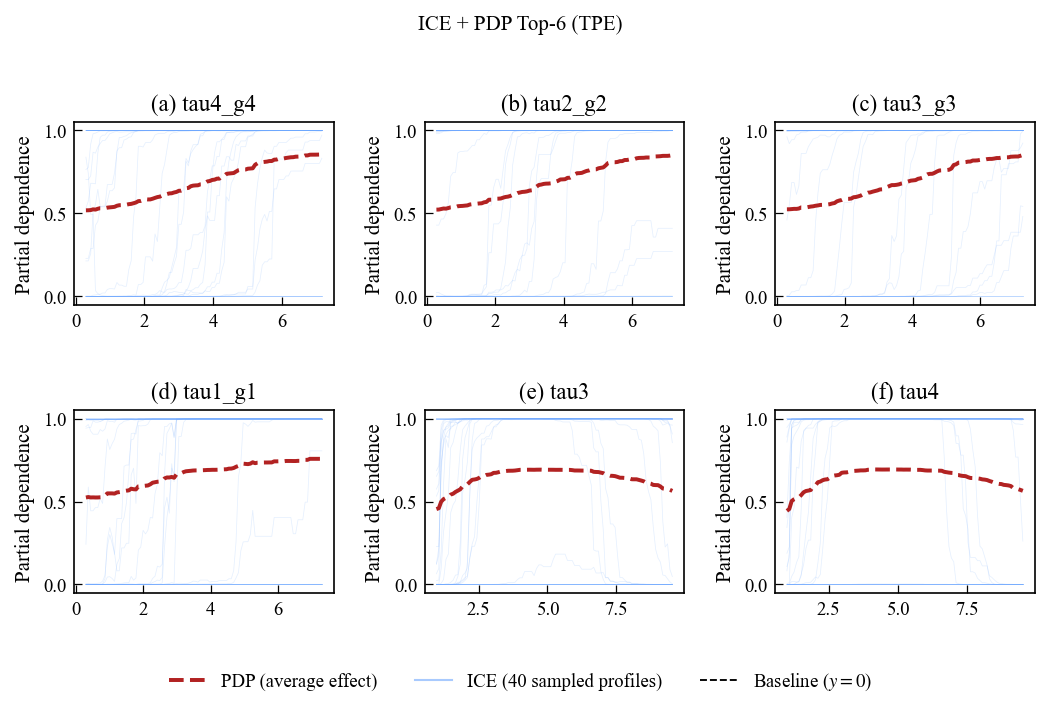

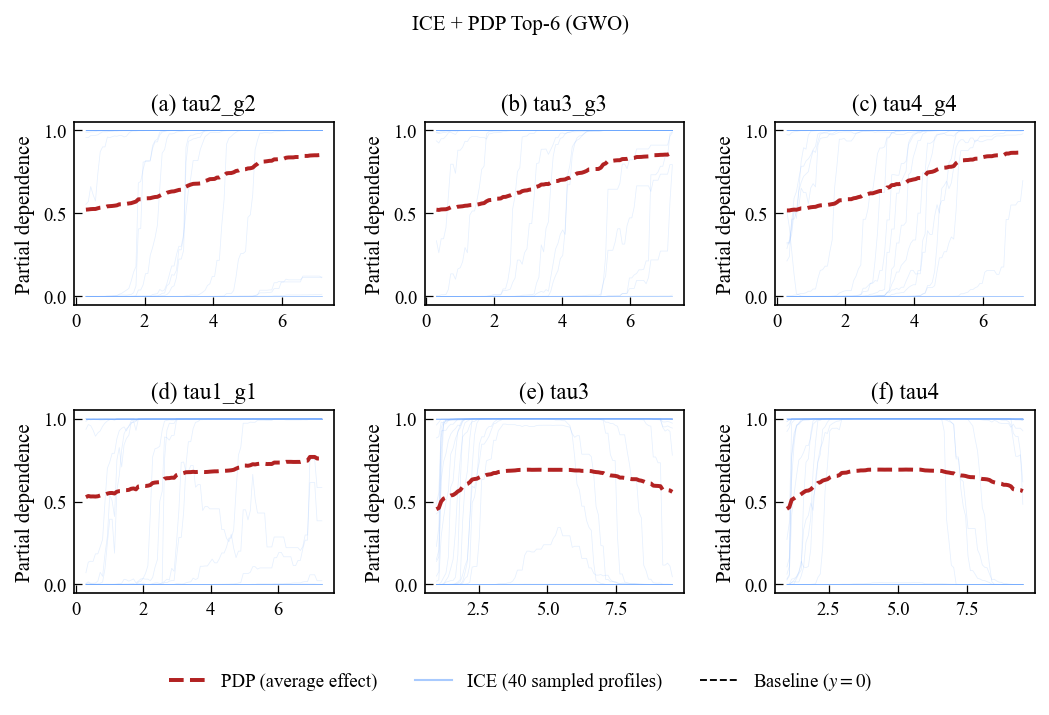

Saved: ice_pdp_tpe_sum_logic.(png/pdf), ice_pdp_gwo_sum_logic.(png/pdf)


In [41]:
from matplotlib.lines import Line2D

for bundle, prefix in [(bundle_t, "tpe"), (bundle_g, "gwo")]:
    top6_features = bundle["top6"]
    feature_to_idx = {f: i for i, f in enumerate(selected_features)}
    placeholder_names = [" " * (i + 1) for i in range(len(selected_features))]

    fig, axes = plt.subplots(2, 3, figsize=(IEEE_DOUBLE_COL, 4.5))
    axes = axes.flatten()

    for i, feat in enumerate(top6_features):
        ax = axes[i]
        feat_idx = feature_to_idx[feat]

        pd_display = PartialDependenceDisplay.from_estimator(
            bundle["pipe"],
            X_test_sel,
            features=[feat_idx],
            feature_names=placeholder_names,
            kind="both",
            subsample=40,
            random_state=RANDOM_STATE,
            ice_lines_kw={"color": "#6EA8FE", "alpha": 0.18, "linewidth": 0.35},
            pd_line_kw={"color": "#B22222", "linewidth": 1.9, "linestyle": "--"},
            ax=ax,
        )

        if hasattr(pd_display, "deciles_vlines_"):
            for artist in np.ravel(pd_display.deciles_vlines_):
                if artist is not None:
                    artist.set_visible(False)

        if ax.legend_ is not None:
            ax.legend_.remove()

        ax.set_title(f"({chr(97+i)}) {feat}", pad=6)
        ax.set_xlabel("")
        ax.xaxis.label.set_visible(False)
        if i % 3 == 0:
            ax.set_ylabel("Partial dependence")
        else:
            ax.set_ylabel("")

        ax.axhline(0, color="black", linestyle="--", linewidth=0.7)
        clean_ax(ax, left_label=(i % 3 == 0))
        ax.tick_params(axis="x", pad=2)

    for subplot_ax in fig.axes:
        if subplot_ax.legend_ is not None:
            subplot_ax.legend_.remove()

    legend_handles = [
        Line2D([0], [0], color="#B22222", linewidth=1.9, linestyle="--", label="PDP (average effect)"),
        Line2D([0], [0], color="#6EA8FE", linewidth=1.0, alpha=0.6, label="ICE (40 sampled profiles)"),
        Line2D([0], [0], color="black", linestyle="--", linewidth=0.9, label="Baseline ($y=0$)"),
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, -0.01),
    )
    fig.suptitle(f"ICE + PDP Top-6 ({bundle['name']})", fontsize=10, y=1.02)
    fig.subplots_adjust(hspace=0.35, wspace=0.25)
    fig.tight_layout(rect=[0, 0.05, 1, 1])

    save_fig_pair(fig, FIG_XAI / f"ice_pdp_{prefix}_sum_logic")
    plt.show()

print("Saved: ice_pdp_tpe_sum_logic.(png/pdf), ice_pdp_gwo_sum_logic.(png/pdf)")

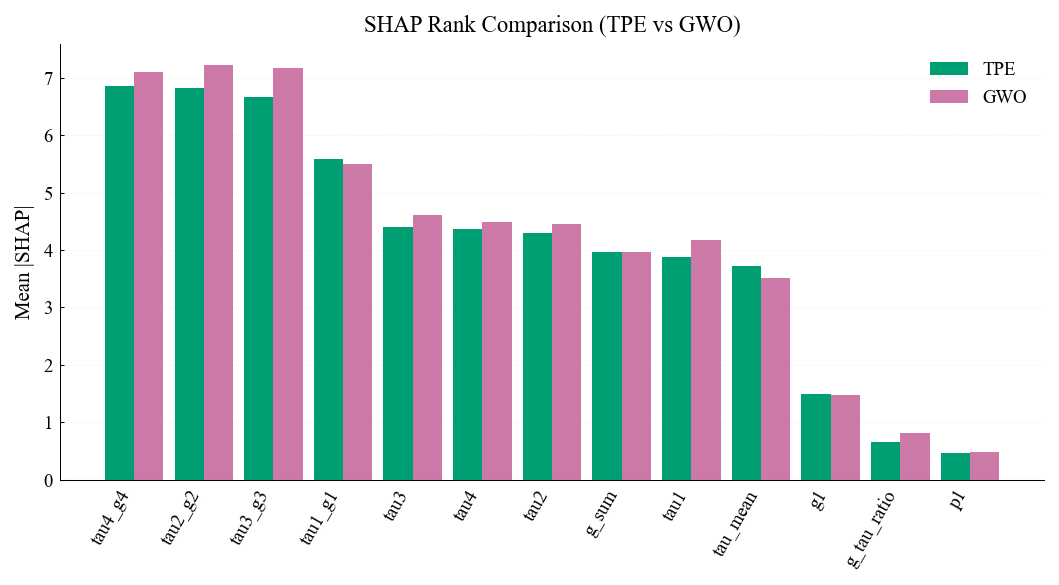

Part B outputs saved.


In [37]:
cmp_df = bundle_t["imp"][["Feature", "Mean_Absolute_SHAP"]].rename(columns={"Mean_Absolute_SHAP": "TPE"})
cmp_df = cmp_df.merge(
    bundle_g["imp"][["Feature", "Mean_Absolute_SHAP"]].rename(columns={"Mean_Absolute_SHAP": "GWO"}),
    on="Feature",
    how="inner",
)
cmp_df = cmp_df.sort_values("TPE", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(IEEE_DOUBLE_COL, 4.0))
x = np.arange(len(cmp_df))
w = 0.42
ax.bar(x - w / 2, cmp_df["TPE"], width=w, color=CB_GREEN, label="TPE")
ax.bar(x + w / 2, cmp_df["GWO"], width=w, color=CB_RED, label="GWO")
ax.set_xticks(x)
ax.set_xticklabels(cmp_df["Feature"], rotation=60, ha="right")
ax.set_ylabel("Mean |SHAP|")
ax.set_title("SHAP Rank Comparison (TPE vs GWO)")
ax.legend(frameon=False)
clean_ax(ax)
plt.tight_layout()
save_fig_pair(fig, FIG_XAI / "shap_rank_comparison_sum_logic")
plt.show()

pd.DataFrame(local_rows).to_csv(RESULTS_DIR / "xai_local_case_summary_sum_logic.csv", index=False)
cmp_df.to_csv(RESULTS_DIR / "xai_feature_importance_comparison_sum_logic.csv", index=False)
print("Part B outputs saved.")

## Part C - Ablation Study (Feature Engineering + HPO Impact)

In [48]:
def evaluate_config(config_id: str, feature_set: str, pipe: Pipeline, Xtr: pd.DataFrame, Xte: pd.DataFrame, ytr, yte):
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xte)
    proba = pipe.predict_proba(Xte)[:, 1]
    point = compute_metric_dict(yte.to_numpy(), pred, proba, proba)
    ci = bootstrap_metric_cis(yte.to_numpy(), pred, proba, proba)
    row = {"ID": config_id, "Feature_Set": feature_set}
    row.update(point)
    for m in METRICS:
        row[f"{m}_CI_Lower"] = ci[m][0]
        row[f"{m}_CI_Upper"] = ci[m][1]
    return row

def row_to_cfg(row, config_id, label):
    out = {"ID": config_id, "Feature_Set": label}
    for m in METRICS:
        out[m] = float(row[m])
        out[f"{m}_CI_Lower"] = float(row.get(f"{m}_CI_Lower", np.nan))
        out[f"{m}_CI_Upper"] = float(row.get(f"{m}_CI_Upper", np.nan))
    return out

# Evaluate configurations A, B — Default params, directly fitted here
cfg_a = evaluate_config("A", "Raw(12)+Default",        make_lgbm_pipeline(None, "Raw"),            X_train_raw, X_test_raw, y_train, y_test)
cfg_b = evaluate_config("B", "Engineered(19)+Default", make_lgbm_pipeline(None, "Raw"),            X_train_eng, X_test_eng, y_train, y_test)

# F, G — Engineered(19) with HPO: fills the missing cells in the 3×3 matrix
# This isolates the feature-selection effect by holding HPO method constant (D vs F, E vs G).
cfg_f = evaluate_config("F", "Engineered(19)+TPE",     make_lgbm_pipeline(tpe_params, tpe_scaler), X_train_eng, X_test_eng, y_train, y_test)
cfg_g = evaluate_config("G", "Engineered(19)+GWO",     make_lgbm_pipeline(gwo_params, gwo_scaler), X_train_eng, X_test_eng, y_train, y_test)

# Load pre-computed results from sum_logic (Selected(13) features)
row_c = baseline_test[(baseline_test["Model"]=="LGBM") & (baseline_test["Split"]=="Test")].iloc[0]
row_d = tpe_test[(tpe_test["Model"]=="LGBM") & (tpe_test["Split"]=="Test")].iloc[0]
row_e = gwo_test[(gwo_test["Model"]=="LGBM") & (gwo_test["Split"]=="Test")].iloc[0]

cfg_c = row_to_cfg(row_c, "C", "Selected(13)+Baseline")
cfg_d = row_to_cfg(row_d, "D", "Selected(13)+TPE")
cfg_e = row_to_cfg(row_e, "E", "Selected(13)+GWO")

# Row order: grouped by feature set — Raw | Engineered | Selected
ablation_df = pd.DataFrame([cfg_a, cfg_b, cfg_f, cfg_g, cfg_c, cfg_d, cfg_e])
base_acc = float(ablation_df.loc[ablation_df["ID"]=="A", "Accuracy"].iloc[0])
ablation_df["Delta_Acc_vs_A"] = ablation_df["Accuracy"] - base_acc
ablation_df.to_csv(RESULTS_DIR / "ablation_lgbm_summary_sum_logic.csv", index=False)

print("C1 done: Full 3×3 ablation matrix evaluated and saved.")
print(ablation_df[["ID", "Feature_Set", "Accuracy", "F1", "AUC", "Delta_Acc_vs_A"]].to_string(index=False))

C1 done: Full 3×3 ablation matrix evaluated and saved.
ID            Feature_Set  Accuracy       F1      AUC  Delta_Acc_vs_A
 A        Raw(12)+Default  0.960250 0.969168 0.994607        0.000000
 B Engineered(19)+Default  0.974333 0.979990 0.997244        0.014083
 F     Engineered(19)+TPE  0.998750 0.999021 0.999987        0.038500
 G     Engineered(19)+GWO  0.999000 0.999217 0.999998        0.038750
 C  Selected(13)+Baseline  0.971083 0.977478 0.996897        0.010833
 D       Selected(13)+TPE  0.999500 0.999608 0.999997        0.039250
 E       Selected(13)+GWO  0.999000 0.999217 0.999996        0.038750


In [49]:
from IPython.display import display as ipy_display

print(f"Available columns: {ablation_df.columns.tolist()}")
cols_to_display = ["ID", "Feature_Set", "Accuracy", "F1", "AUC", "LogLoss", "Delta_Acc_vs_A"]
cols_to_display = [c for c in cols_to_display if c in ablation_df.columns]
if "MCC" in ablation_df.columns:
    cols_to_display.insert(3, "MCC")  # Insert MCC after F1

ipy_display(ablation_df[cols_to_display])
print("C2 done: Ablation summary table displayed.")

Available columns: ['ID', 'Feature_Set', 'Accuracy', 'Precision', 'Recall', 'F1', 'Kappa', 'MCC', 'AUC', 'LogLoss', 'Accuracy_CI_Lower', 'Accuracy_CI_Upper', 'Precision_CI_Lower', 'Precision_CI_Upper', 'Recall_CI_Lower', 'Recall_CI_Upper', 'F1_CI_Lower', 'F1_CI_Upper', 'AUC_CI_Lower', 'AUC_CI_Upper', 'LogLoss_CI_Lower', 'LogLoss_CI_Upper', 'Kappa_CI_Lower', 'Kappa_CI_Upper', 'MCC_CI_Lower', 'MCC_CI_Upper', 'Delta_Acc_vs_A']


,ID,Feature_Set,Accuracy,MCC,F1,AUC,LogLoss,Delta_Acc_vs_A
0,A,Raw(12)+Default,0.960250,0.913640,0.969168,0.994607,0.129007,0.000000
1,B,Engineered(19)+Default,0.974333,0.944311,0.979990,0.997244,0.101729,0.014083
2,F,Engineered(19)+TPE,0.998750,0.997294,0.999021,0.999987,0.003765,0.038500
3,G,Engineered(19)+GWO,0.999000,0.997835,0.999217,0.999998,0.002333,0.038750
4,C,Selected(13)+Baseline,0.971083,0.937239,0.977478,0.996897,0.106920,0.010833
5,D,Selected(13)+TPE,0.999500,0.998917,0.999608,0.999997,0.002155,0.039250
6,E,Selected(13)+GWO,0.999000,0.997835,0.999217,0.999996,0.002736,0.038750


C2 done: Ablation summary table displayed.


In [ ]:
ablation_df

,ID,Feature_Set,Accuracy,Precision,Recall,F1,Kappa,MCC,AUC,LogLoss,...,F1_CI_Upper,AUC_CI_Lower,AUC_CI_Upper,LogLoss_CI_Lower,LogLoss_CI_Upper,Kappa_CI_Lower,Kappa_CI_Upper,MCC_CI_Lower,MCC_CI_Upper,Delta_Acc_vs_A
0,A,Raw(12)+Default,0.960250,0.959309,0.979232,0.969168,0.913258,0.913640,0.994607,0.129007,...,0.971899,0.993830,0.995340,0.124811,0.133085,0.905875,0.920683,0.906245,0.921015,0.000000
1,B,Engineered(19)+Default,0.974333,0.974922,0.985110,0.979990,0.944212,0.944311,0.997244,0.101729,...,0.982179,0.996736,0.997734,0.097952,0.105527,0.937818,0.950467,0.937935,0.950539,0.014083
2,F,Engineered(19)+TPE,0.998750,0.998565,0.999478,0.999021,0.997293,0.997294,0.999987,0.003765,...,0.999539,0.999970,0.999999,0.002211,0.005601,0.995846,0.998726,0.995848,0.998726,0.038500
3,G,Engineered(19)+GWO,0.999000,0.998825,0.999608,0.999217,0.997834,0.997835,0.999998,0.002333,...,0.999610,0.999995,0.999999,0.001462,0.003361,0.996576,0.998918,0.996578,0.998918,0.038750
4,C,Selected(13)+Baseline,0.971083,0.971488,0.983542,0.977478,0.937100,0.937239,0.996897,0.106920,...,0.979781,0.996368,0.997397,0.103143,0.110710,0.930425,0.943676,0.930608,0.943769,0.010833
5,D,Selected(13)+TPE,0.999500,0.999478,0.999739,0.999608,0.998917,0.998917,0.999997,0.002155,...,0.999870,0.999994,1.000000,0.001323,0.003149,0.998013,0.999641,0.998014,0.999641,0.039250
6,E,Selected(13)+GWO,0.999000,0.998825,0.999608,0.999217,0.997834,0.997835,0.999996,0.002736,...,0.999611,0.999992,0.999999,0.001688,0.003934,0.996571,0.998927,0.996571,0.998927,0.038750


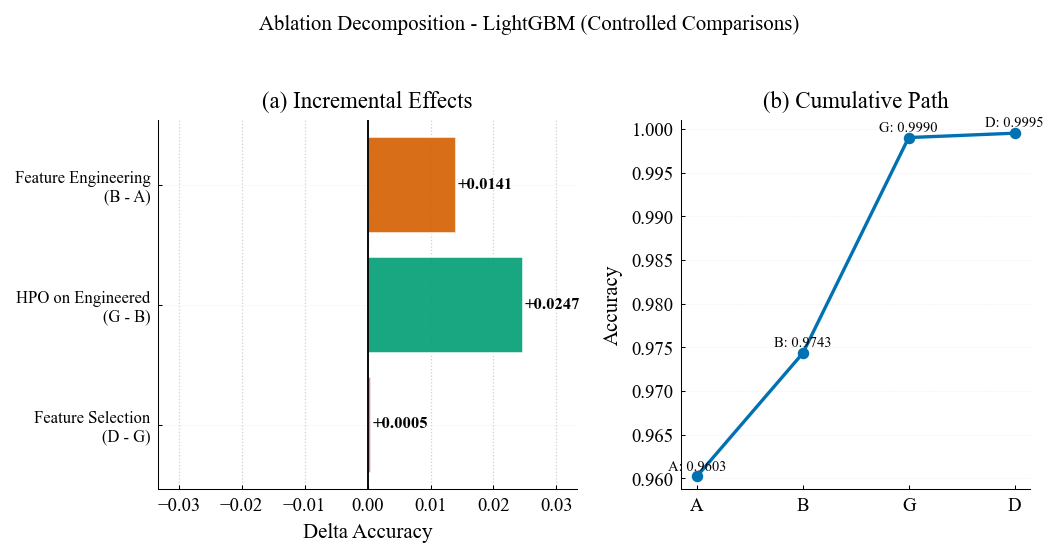

C3 done: Ablation decomposition chart saved.
  Base accuracy (A): 0.9603
  Feature Engineering (B-A): +0.0141
  HPO on Engineered (G-B): +0.0247
  Feature Selection (D-G): +0.0005
  Net gain (A -> D): +0.0393


In [54]:
# Controlled decomposition for readability in publication figures
# Path: A (Raw+Default) -> B (Engineered+Default) -> best(F,G) -> best(D,E)
acc_a = float(ablation_df[ablation_df["ID"] == "A"]["Accuracy"].iloc[0])
acc_b = float(ablation_df[ablation_df["ID"] == "B"]["Accuracy"].iloc[0])

best_eng_hpo = ablation_df[ablation_df["ID"].isin(["F", "G"])].sort_values("Accuracy", ascending=False).iloc[0]
acc_fg = float(best_eng_hpo["Accuracy"])

best_sel_hpo = ablation_df[ablation_df["ID"].isin(["D", "E"])].sort_values("Accuracy", ascending=False).iloc[0]
acc_de = float(best_sel_hpo["Accuracy"])

# Incremental effects (the quantities reviewers care about)
delta_fe = acc_b - acc_a
delta_hpo_eng = acc_fg - acc_b
delta_fs = acc_de - acc_fg

delta_rows = [
    ("Feature Engineering\n(B - A)", delta_fe, CB_ORANGE),
    (f"HPO on Engineered\n({best_eng_hpo['ID']} - B)", delta_hpo_eng, CB_GREEN),
    (f"Feature Selection\n({best_sel_hpo['ID']} - {best_eng_hpo['ID']})", delta_fs, CB_RED),
]

stages = ["A", "B", best_eng_hpo["ID"], best_sel_hpo["ID"]]
acc_path = [acc_a, acc_b, acc_fg, acc_de]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(IEEE_DOUBLE_COL, 3.6), gridspec_kw={"width_ratios": [1.2, 1.0]})

# Panel (a): incremental contributions only (centered around zero)
ypos = np.arange(len(delta_rows))
vals = [r[1] for r in delta_rows]
colors = [r[2] for r in delta_rows]
labels = [r[0] for r in delta_rows]

bars = ax1.barh(ypos, vals, color=colors, alpha=0.9, edgecolor="white", linewidth=0.8)
ax1.axvline(0, color="black", linewidth=0.9)

lim = max(0.002, max(abs(v) for v in vals) * 1.35)
ax1.set_xlim(-lim, lim)
ax1.set_yticks(ypos)
ax1.set_yticklabels(labels, fontsize=8)
ax1.invert_yaxis()
ax1.set_xlabel("Delta Accuracy")
ax1.set_title("(a) Incremental Effects")
ax1.grid(axis="x", linestyle=":", linewidth=0.6, alpha=0.6)

for bar, v in zip(bars, vals):
    x = v + (0.00025 if v >= 0 else -0.00025)
    ha = "left" if v >= 0 else "right"
    ax1.text(x, bar.get_y() + bar.get_height() / 2, f"{v:+.4f}", va="center", ha=ha, fontsize=8, fontweight="bold")

clean_ax(ax1)

# Panel (b): cumulative trajectory across stages
x = np.arange(len(stages))
ax2.plot(x, acc_path, color=CB_BLUE, marker="o", markersize=4.5, linewidth=1.6)
for xi, yi, s in zip(x, acc_path, stages):
    ax2.text(xi, yi + 0.00035, f"{s}: {yi:.4f}", ha="center", va="bottom", fontsize=7)

ymin = min(acc_path) - 0.0015
ymax = max(acc_path) + 0.0015
ax2.set_ylim(ymin, ymax)
ax2.set_xticks(x)
ax2.set_xticklabels(["A", "B", f"{best_eng_hpo['ID']}", f"{best_sel_hpo['ID']}"])
ax2.set_ylabel("Accuracy")
ax2.set_title("(b) Cumulative Path")
ax2.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.6)
clean_ax(ax2)

fig.suptitle("Ablation Decomposition - LightGBM (Controlled Comparisons)", y=1.02, fontsize=10)
plt.tight_layout()
save_fig_pair(fig, FIG_ABL / "ablation_decomposition_sum_logic")
plt.show()

print("C3 done: Ablation decomposition chart saved.")
print(f"  Base accuracy (A): {acc_a:.4f}")
print(f"  Feature Engineering (B-A): {delta_fe:+.4f}")
print(f"  HPO on Engineered ({best_eng_hpo['ID']}-B): {delta_hpo_eng:+.4f}")
print(f"  Feature Selection ({best_sel_hpo['ID']}-{best_eng_hpo['ID']}): {delta_fs:+.4f}")
print(f"  Net gain (A -> {best_sel_hpo['ID']}): {acc_de - acc_a:+.4f}")

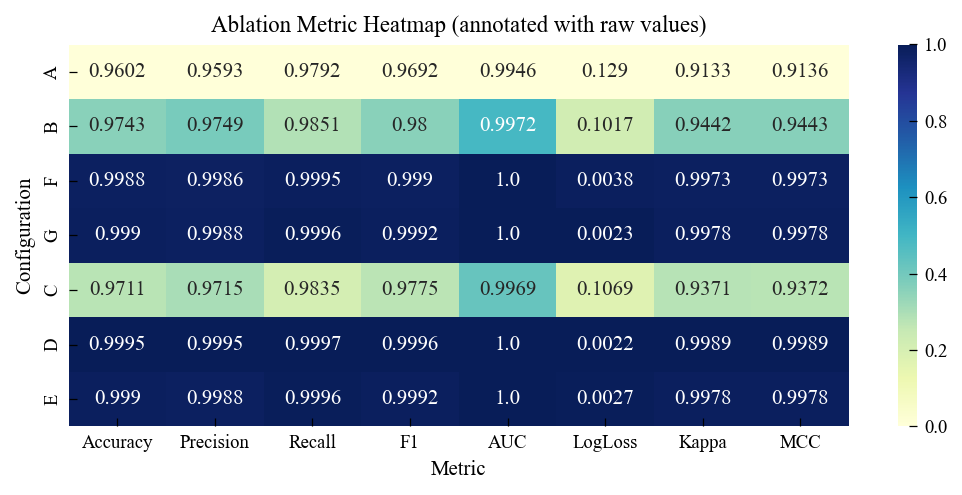

C4 done: Ablation metric heatmap saved.


In [55]:
hm = ablation_df[["ID", *METRICS]].copy().set_index("ID")
hm_norm = hm.copy()
for c in hm_norm.columns:
    col = hm_norm[c].astype(float)
    if c == "LogLoss":
        col = -col
    hm_norm[c] = (col - col.min()) / (col.max() - col.min() + 1e-12)

fig, ax = plt.subplots(figsize=(IEEE_DOUBLE_COL, 3.4))
sns.heatmap(hm_norm, annot=hm.round(4), fmt="", cmap="YlGnBu", cbar=True, ax=ax)
ax.set_title("Ablation Metric Heatmap (annotated with raw values)")
ax.set_xlabel("Metric")
ax.set_ylabel("Configuration")
plt.tight_layout()
save_fig_pair(fig, FIG_ABL / "ablation_heatmap_sum_logic")
plt.show()

print("C4 done: Ablation metric heatmap saved.")

In [57]:
from IPython.display import display as ipy_display

def bootstrap_acc(y_true, pred, n=1000):
    rng = np.random.default_rng(RANDOM_STATE)
    idx = np.arange(len(y_true))
    out = []
    for _ in range(n):
        s = rng.choice(idx, size=len(idx), replace=True)
        out.append(accuracy_score(y_true[s], pred[s]))
    return np.array(out)

# Re-fit all 7 configurations to obtain predictions for bootstrap significance testing.
# pipe_baseline / pipe_tpe / pipe_gwo (on Selected) are already fitted in cell 4 — reuse them.
pipe_f_eng = make_lgbm_pipeline(tpe_params, tpe_scaler).fit(X_train_eng, y_train)  # F: Eng+TPE
pipe_g_eng = make_lgbm_pipeline(gwo_params, gwo_scaler).fit(X_train_eng, y_train)  # G: Eng+GWO

boot_a = bootstrap_acc(y_test.to_numpy(), make_lgbm_pipeline(None, "Raw").fit(X_train_raw, y_train).predict(X_test_raw))
boot_b = bootstrap_acc(y_test.to_numpy(), make_lgbm_pipeline(None, "Raw").fit(X_train_eng, y_train).predict(X_test_eng))
boot_c = bootstrap_acc(y_test.to_numpy(), pipe_baseline.predict(X_test_sel))   # C: Selected+Baseline
boot_d = bootstrap_acc(y_test.to_numpy(), pipe_tpe.predict(X_test_sel))        # D: Selected+TPE
boot_e = bootstrap_acc(y_test.to_numpy(), pipe_gwo.predict(X_test_sel))        # E: Selected+GWO
boot_f = bootstrap_acc(y_test.to_numpy(), pipe_f_eng.predict(X_test_eng))      # F: Engineered+TPE
boot_g = bootstrap_acc(y_test.to_numpy(), pipe_g_eng.predict(X_test_eng))      # G: Engineered+GWO

comparisons = [
    # Core ablation path
    ("B_vs_A",  boot_b, boot_a, "Feature engineering effect (Default HPO)"),
    ("D_vs_A",  boot_d, boot_a, "Full pipeline effect (Selected+TPE vs Raw+Default)"),
    ("E_vs_A",  boot_e, boot_a, "Full pipeline effect (Selected+GWO vs Raw+Default)"),
    # HPO effect on Engineered features (B→F, B→G)
    ("F_vs_B",  boot_f, boot_b, "HPO effect on Engineered: TPE vs Default"),
    ("G_vs_B",  boot_g, boot_b, "HPO effect on Engineered: GWO vs Default"),
    # Feature selection effect at controlled HPO (key controlled comparison)
    ("D_vs_F",  boot_d, boot_f, "Feature selection effect at TPE (Selected vs Engineered)"),
    ("E_vs_G",  boot_e, boot_g, "Feature selection effect at GWO (Selected vs Engineered)"),
    # HPO comparison on Selected features
    ("D_vs_E",  boot_d, boot_e, "TPE vs GWO on Selected features"),
]

sig_rows = []
for name, x, yb, description in comparisons:
    delta = x - yb
    sig_rows.append({
        "Comparison":        name,
        "Description":       description,
        "Mean_Delta_Acc":    float(delta.mean()),
        "CI_Lower":          float(np.percentile(delta, 2.5)),
        "CI_Upper":          float(np.percentile(delta, 97.5)),
        "Significant_95pct": bool((np.percentile(delta, 2.5) > 0) or (np.percentile(delta, 97.5) < 0)),
    })

sig_df = pd.DataFrame(sig_rows)
sig_df.to_csv(RESULTS_DIR / "ablation_significance_sum_logic.csv", index=False)

ipy_display(sig_df)
print("C5 done: Ablation significance testing completed.")

,Comparison,Description,Mean_Delta_Acc,CI_Lower,CI_Upper,Significant_95pct
0,B_vs_A,Feature engineering effect (Default HPO),0.014074,0.010750,0.017500,True
1,D_vs_A,Full pipeline effect (Selected+TPE vs Raw+Defa...,0.039171,0.035833,0.042669,True
2,E_vs_A,Full pipeline effect (Selected+GWO vs Raw+Defa...,0.038672,0.035333,0.042167,True
3,F_vs_B,HPO effect on Engineered: TPE vs Default,0.024362,0.021665,0.027250,True
4,G_vs_B,HPO effect on Engineered: GWO vs Default,0.024599,0.021833,0.027583,True
5,D_vs_F,Feature selection effect at TPE (Selected vs E...,0.000735,0.000167,0.001333,True
6,E_vs_G,Feature selection effect at GWO (Selected vs E...,-0.000001,-0.000500,0.000500,False
7,D_vs_E,TPE vs GWO on Selected features,0.000499,0.000083,0.001000,True


C5 done: Ablation significance testing completed.


In [59]:
sig_df

,Comparison,Description,Mean_Delta_Acc,CI_Lower,CI_Upper,Significant_95pct
0,B_vs_A,Feature engineering effect (Default HPO),0.014074,0.010750,0.017500,True
1,D_vs_A,Full pipeline effect (Selected+TPE vs Raw+Defa...,0.039171,0.035833,0.042669,True
2,E_vs_A,Full pipeline effect (Selected+GWO vs Raw+Defa...,0.038672,0.035333,0.042167,True
3,F_vs_B,HPO effect on Engineered: TPE vs Default,0.024362,0.021665,0.027250,True
4,G_vs_B,HPO effect on Engineered: GWO vs Default,0.024599,0.021833,0.027583,True
5,D_vs_F,Feature selection effect at TPE (Selected vs E...,0.000735,0.000167,0.001333,True
6,E_vs_G,Feature selection effect at GWO (Selected vs E...,-0.000001,-0.000500,0.000500,False
7,D_vs_E,TPE vs GWO on Selected features,0.000499,0.000083,0.001000,True


In [58]:
print("Part C - Ablation Study (Complete)\n")
print("=" * 70)
print("\nKey Output Files:")
ablation_outputs = [
    RESULTS_DIR / "ablation_lgbm_summary_sum_logic.csv",
    RESULTS_DIR / "ablation_significance_sum_logic.csv",
    FIG_ABL / "ablation_decomposition_sum_logic.png",
    FIG_ABL / "ablation_heatmap_sum_logic.png",
]
for p in ablation_outputs:
    status = "✓" if p.exists() else "✗"
    print(f"{status} {p.name}")
print("=" * 70)
print("\nPart C outputs saved successfully.")

Part C - Ablation Study (Complete)


Key Output Files:
✓ ablation_lgbm_summary_sum_logic.csv
✓ ablation_significance_sum_logic.csv
✓ ablation_decomposition_sum_logic.png
✓ ablation_heatmap_sum_logic.png

Part C outputs saved successfully.


## Part D - Statistical Significance Testing

This section tests whether observed performance differences are statistically significant.

### Data provenance
All statistical inputs in this section are sourced from persisted sum_logic artifacts under results/tables/sum_logic, specifically:
- baseline_test_results_with_ci.csv
- tpe_test_results_with_ci.csv
- gwo_test_results_with_ci.csv

### Statistical design
1. Primary inferential test: paired Wilcoxon signed-rank test (two-sided).
2. Robustness check: paired t-test.
3. Effect size reporting: paired Cohen's d and rank-biserial correlation.
4. Incomplete-run handling: pairwise comparisons are computed on the intersection of available models only.
5. Multiplicity control: Holm adjustment across the three primary comparisons.

In [63]:
# paired significance tests on model-level test accuracy
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon, ttest_rel
from IPython.display import display as ipy_display

# -----------------------------------------------------------------------------
# Load directly from persisted sum_logic artifacts for reproducibility
# -----------------------------------------------------------------------------
baseline_path = RESULTS_DIR / 'baseline_test_results_with_ci.csv'
tpe_path = RESULTS_DIR / 'tpe_test_results_with_ci.csv'
gwo_path = RESULTS_DIR / 'gwo_test_results_with_ci.csv'

baseline_df = pd.read_csv(baseline_path)
tpe_df = pd.read_csv(tpe_path)
gwo_df = pd.read_csv(gwo_path)

baseline_test = baseline_df.loc[baseline_df['Split'] == 'Test', ['Model', 'Accuracy']].dropna().drop_duplicates('Model')
tpe_test = tpe_df.loc[tpe_df['Split'] == 'Test', ['Model', 'Accuracy']].dropna().drop_duplicates('Model')
gwo_test = gwo_df.loc[gwo_df['Split'] == 'Test', ['Model', 'Accuracy']].dropna().drop_duplicates('Model')

baseline_test = baseline_test.rename(columns={'Accuracy': 'Baseline_Accuracy'})
tpe_test = tpe_test.rename(columns={'Accuracy': 'TPE_Accuracy'})
gwo_test = gwo_test.rename(columns={'Accuracy': 'GWO_Accuracy'})

print('Model availability from sum_logic artifacts:')
print(f"- Baseline models: {len(baseline_test)}")
print(f"- TPE models:      {len(tpe_test)}")
print(f"- GWO models:      {len(gwo_test)}")

def holm_bonferroni(p_values):
    m = len(p_values)
    order = np.argsort(p_values)
    ordered = np.array(p_values, dtype=float)[order]
    adjusted = np.empty(m, dtype=float)

    running_max = 0.0
    for i, p in enumerate(ordered):
        adj = (m - i) * p
        running_max = max(running_max, adj)
        adjusted[i] = min(running_max, 1.0)

    out = np.empty(m, dtype=float)
    out[order] = adjusted
    return out

def cohens_d_paired(deltas):
    deltas = np.asarray(deltas, dtype=float)
    if deltas.size < 2:
        return np.nan
    sd = np.std(deltas, ddof=1)
    if np.isclose(sd, 0.0):
        return np.nan
    return float(np.mean(deltas) / sd)

def rank_biserial_from_deltas(deltas):
    deltas = np.asarray(deltas, dtype=float)
    nz = deltas[~np.isclose(deltas, 0.0)]
    if nz.size == 0:
        return np.nan

    ranks = pd.Series(np.abs(nz)).rank(method='average').to_numpy(dtype=float)
    w_plus = float(ranks[nz > 0].sum())
    w_minus = float(ranks[nz < 0].sum())
    denom = w_plus + w_minus
    if np.isclose(denom, 0.0):
        return np.nan
    return float((w_plus - w_minus) / denom)

def paired_stats(left_name, right_name, merged_df, left_col, right_col, all_model_pool):
    models_used = merged_df['Model'].tolist()
    skipped = sorted(set(all_model_pool) - set(models_used))

    deltas = merged_df[left_col].to_numpy() - merged_df[right_col].to_numpy()
    n_models = len(deltas)

    try:
        p_w = float(wilcoxon(merged_df[left_col], merged_df[right_col], alternative='two-sided', zero_method='wilcox').pvalue)
    except ValueError:
        p_w = np.nan

    try:
        p_t = float(ttest_rel(merged_df[left_col], merged_df[right_col], alternative='two-sided').pvalue)
    except Exception:
        p_t = np.nan

    return {
        'Comparison': f'{left_name} vs {right_name}',
        'N_Models': int(n_models),
        'Models_Used': ';'.join(models_used),
        'Skipped_Models': ';'.join(skipped) if skipped else '',
        'Mean_Delta_Acc': float(np.mean(deltas)) if n_models else np.nan,
        'Median_Delta_Acc': float(np.median(deltas)) if n_models else np.nan,
        'Wins_Left_Better': int(np.sum(deltas > 0)),
        'Losses_Left_Worse': int(np.sum(deltas < 0)),
        'Ties': int(np.sum(np.isclose(deltas, 0.0))),
        'Cohens_d_paired': cohens_d_paired(deltas),
        'RankBiserial_r': rank_biserial_from_deltas(deltas),
        'Wilcoxon_p': p_w,
        'Paired_t_p': p_t,
    }

b_tpe = baseline_test.merge(tpe_test, on='Model', how='inner').sort_values('Model').reset_index(drop=True)
b_gwo = baseline_test.merge(gwo_test, on='Model', how='inner').sort_values('Model').reset_index(drop=True)
tpe_gwo = tpe_test.merge(gwo_test, on='Model', how='inner').sort_values('Model').reset_index(drop=True)

all_models_union = sorted(set(baseline_test['Model']).union(set(tpe_test['Model'])).union(set(gwo_test['Model'])))

sig_rows = [
    paired_stats('Baseline', 'TPE', b_tpe, 'Baseline_Accuracy', 'TPE_Accuracy', all_models_union),
    paired_stats('Baseline', 'GWO', b_gwo, 'Baseline_Accuracy', 'GWO_Accuracy', all_models_union),
    paired_stats('TPE', 'GWO', tpe_gwo, 'TPE_Accuracy', 'GWO_Accuracy', all_models_union),
]

sig_df = pd.DataFrame(sig_rows)
sig_df['Adj_p_Holm'] = holm_bonferroni(sig_df['Wilcoxon_p'].fillna(1.0).to_list())
sig_df['Significant_0_05'] = sig_df['Adj_p_Holm'] < 0.05

sig_out = RESULTS_DIR / 'model_performance_significance.csv'
sig_df.to_csv(sig_out, index=False)

ipy_display(sig_df[['Comparison', 'N_Models', 'Mean_Delta_Acc', 'Median_Delta_Acc', 'Cohens_d_paired', 'RankBiserial_r', 'Wilcoxon_p', 'Adj_p_Holm', 'Paired_t_p', 'Significant_0_05', 'Skipped_Models']])
print(f"Saved: {sig_out}")

Model availability from sum_logic artifacts:
- Baseline models: 14
- TPE models:      14
- GWO models:      11


,Comparison,N_Models,Mean_Delta_Acc,Median_Delta_Acc,Cohens_d_paired,RankBiserial_r,Wilcoxon_p,Adj_p_Holm,Paired_t_p,Significant_0_05,Skipped_Models
0,Baseline vs TPE,14,-0.020500,-0.012083,-0.862168,-0.974359,0.002873,0.00862,0.006628,True,
1,Baseline vs GWO,11,-0.016470,-0.005750,-0.843251,-1.000000,0.003906,0.00862,0.018900,True,GB;RF;SVM
2,TPE vs GWO,11,0.000902,0.000000,0.266409,0.111111,0.843750,0.84375,0.397669,False,GB;RF;SVM


Saved: C:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01\results\tables\sum_logic\model_performance_significance.csv


In [64]:
# Publication-ready interpretation helper
from IPython.display import display as ipy_display

print('Part D interpretation notes:')
print('- Statistical inputs are sourced from results/tables/sum_logic artifacts (Baseline/TPE/GWO test result files).')
print('- Primary inference uses paired Wilcoxon tests across all common models with Holm correction.')
print('- Effect sizes are reported as paired Cohen\'s d and rank-biserial correlation.')
print('- Comparisons involving incomplete GWO outputs use intersection-only model pairing.')
print('- Family-stratified top-2 analysis is supplementary/descriptive only.')

ipy_display(sig_df[['Comparison', 'N_Models', 'Mean_Delta_Acc', 'Median_Delta_Acc', 'Cohens_d_paired', 'RankBiserial_r', 'Wilcoxon_p', 'Adj_p_Holm', 'Significant_0_05', 'Skipped_Models']])

Part D interpretation notes:
- Statistical inputs are sourced from results/tables/sum_logic artifacts (Baseline/TPE/GWO test result files).
- Primary inference uses paired Wilcoxon tests across all common models with Holm correction.
- Effect sizes are reported as paired Cohen's d and rank-biserial correlation.
- Comparisons involving incomplete GWO outputs use intersection-only model pairing.
- Family-stratified top-2 analysis is supplementary/descriptive only.


,Comparison,N_Models,Mean_Delta_Acc,Median_Delta_Acc,Cohens_d_paired,RankBiserial_r,Wilcoxon_p,Adj_p_Holm,Significant_0_05,Skipped_Models
0,Baseline vs TPE,14,-0.020500,-0.012083,-0.862168,-0.974359,0.002873,0.00862,True,
1,Baseline vs GWO,11,-0.016470,-0.005750,-0.843251,-1.000000,0.003906,0.00862,True,GB;RF;SVM
2,TPE vs GWO,11,0.000902,0.000000,0.266409,0.111111,0.843750,0.84375,False,GB;RF;SVM


### Part D.1 - Supplementary Family-Stratified Snapshot (Descriptive)

This subsection is descriptive only and is not used as primary inferential evidence.

Selection rule:
- select top 2 models per family from common TPE-GWO models, ranked by |TPE - GWO| test-accuracy gap;
- force-include LGBM in the Tree-Ensemble family for interpretability continuity.

In [67]:
# Supplementary: two representatives per family (with forced LGBM inclusion)
from IPython.display import display as ipy_display

N_PER_FAMILY = 2

common = tpe_test.merge(gwo_test, on='Model', how='inner').merge(baseline_test, on='Model', how='left')
common['Delta_TPE_minus_GWO'] = common['TPE_Accuracy'] - common['GWO_Accuracy']
common['Abs_Delta_TPE_GWO'] = common['Delta_TPE_minus_GWO'].abs()

family_map = {
    'LR': 'Linear',
    'LinearSVC': 'Linear',
    'SGD': 'Linear',
    'LDA': 'Probabilistic',
    'QDA': 'Probabilistic',
    'NB': 'Probabilistic',
    'KNN': 'Distance',
    'AdaBoost': 'Tree-Ensemble',
    'GB': 'Tree-Ensemble',
    'RF': 'Tree-Ensemble',
    'XGB': 'Tree-Ensemble',
    'LGBM': 'Tree-Ensemble',
    'CB': 'Tree-Ensemble',
    'SVM': 'Kernel',
}
common['Family'] = common['Model'].map(family_map).fillna('Other')

rep_df = (
    common.sort_values(['Family', 'Abs_Delta_TPE_GWO'], ascending=[True, False])
    .groupby('Family', as_index=False, group_keys=False)
    .head(N_PER_FAMILY)
    .reset_index(drop=True)
)

tree_mask = rep_df['Family'] == 'Tree-Ensemble'
tree_selected = rep_df.loc[tree_mask].copy()
tree_pool = common.loc[common['Family'] == 'Tree-Ensemble'].copy()

if not tree_pool.empty and 'LGBM' in set(tree_pool['Model']) and 'LGBM' not in set(tree_selected['Model']):
    lgbm_row = tree_pool.loc[tree_pool['Model'] == 'LGBM'].iloc[[0]]
    if len(tree_selected) >= N_PER_FAMILY:
        drop_idx = tree_selected['Abs_Delta_TPE_GWO'].idxmin()
        rep_df = rep_df.drop(index=drop_idx).reset_index(drop=True)
    rep_df = pd.concat([rep_df, lgbm_row], ignore_index=True)

rep_df = rep_df.sort_values(['Family', 'Abs_Delta_TPE_GWO'], ascending=[True, False]).reset_index(drop=True)

rep_out = RESULTS_DIR / 'representative_models_by_family_top2.csv'
rep_df[['Family', 'Model', 'Baseline_Accuracy', 'TPE_Accuracy', 'GWO_Accuracy', 'Delta_TPE_minus_GWO', 'Abs_Delta_TPE_GWO']].to_csv(rep_out, index=False)

ipy_display(rep_df[['Family', 'Model', 'Baseline_Accuracy', 'TPE_Accuracy', 'GWO_Accuracy', 'Delta_TPE_minus_GWO', 'Abs_Delta_TPE_GWO']])
print(f"Saved: {rep_out}")

,Family,Model,Baseline_Accuracy,TPE_Accuracy,GWO_Accuracy,Delta_TPE_minus_GWO,Abs_Delta_TPE_GWO
0,Distance,KNN,0.939417,0.954167,0.954333,-0.000167,0.000167
1,Linear,SGD,0.895583,0.902833,0.901333,0.001500,0.001500
2,Linear,LinearSVC,0.905167,0.904917,0.905667,-0.000750,0.000750
3,Probabilistic,QDA,0.901583,0.905917,0.905167,0.000750,0.000750
4,Probabilistic,LDA,0.903500,0.903500,0.903500,0.000000,0.000000
5,Tree-Ensemble,AdaBoost,0.893500,0.950667,0.939917,0.010750,0.010750
6,Tree-Ensemble,LGBM,0.971083,0.999500,0.999000,0.000500,0.000500


Saved: C:\Users\omar8\Desktop\2026\Master & Research\smart-grid-stability-v01\results\tables\sum_logic\representative_models_by_family_top2.csv
